# Прогнозирование годовых медицинских расходов пациента на основе табличных данных

# Дополнительное исследование на расширенном датасете

В этом ноутбуке проводится дополнительный эксперимент на расширенном датасете с 100 000 пациентов.  
Цель — проверить, сохраняются ли выводы исходного исследования на более крупном и сложном наборе данных, а также оценить, дают ли ансамблевые методы выигрыш по сравнению с одиночными моделями.

Ссылка: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction/data

## 1. Подготовка данных

В новом датасете набор признаков отличается от исходного, поэтому для корректного сравнения используется только пересекающийся набор признаков:

- демографические признаки: `age`, `gender`;
- показатели здоровья: `bmi`, `diabetes`, `hypertension`, `heart_disease`, `asthma`;
- признаки медицинской нагрузки: `doctor_visits_per_year`, `hospital_admissions`, `medication_count`;
- поведенческие и средовые признаки: `smoker`, `city_type`.

Целевая переменная — `annual_medical_cost`.  
Страховые и claims-признаки исключаются, чтобы избежать утечек данных.

## 2. Разведочный анализ данных

В EDA анализируются:

- распределения числовых признаков;
- выбросы и асимметрия;
- распределения бинарных и категориальных признаков;
- распределение целевой переменной;
- связи признаков с таргетом через `phi_k`, корреляции и визуализации.

По итогам EDA задача выглядит сложнее, чем на исходном синтетическом датасете: таргет сильно скошен вправо, а связи отдельных признаков с расходами в основном слабые или умеренные.

## 3. Базовые модели

Данные делятся на train/test в пропорции 80/20.  
Test set откладывается до финального этапа и не используется для подбора моделей или весов ансамблей.

На train обучаются несколько моделей разных классов:

- `ElasticNet` как лучшая линейная модель;
- `RandomForestRegressor`;
- `ExtraTreesRegressor`;
- `HistGradientBoostingRegressor`;
- `CatBoostRegressor`.

Для линейных моделей используется отдельный preprocessing pipeline с масштабированием числовых признаков и one-hot encoding категориальных признаков.
Для деревянных моделей масштабирование не применяется.  
Для CatBoost категориальные признаки передаются в модель нативно.

## 4. Подбор гиперпараметров

Гиперпараметры подбираются только внутри train:

- для простых моделей используется GridSearchCV / RandomizedSearchCV;
- для бустингов используется Optuna;
- качество оценивается через 5-fold cross-validation.

Основная метрика — `MAE`, так как она показывает среднюю ошибку прогноза в денежных единицах. Дополнительно считаются `RMSE`, `R²` и `MAPE`.

## 5. Out-of-fold predictions

После подбора гиперпараметров для каждой базовой модели строятся out-of-fold предсказания на train.

OOF-предсказания используются для:

- честной оценки качества базовых моделей;
- выбора лучшей одиночной модели;
- расчёта весов ансамблей;
- обучения stacking meta-модели.

Это важно, потому что веса ансамблей не подбираются на test set.

## 6. Ансамблевые подходы

В ноутбуке проверяются несколько способов объединения моделей:

- **Simple Average Ensemble** — простое среднее прогнозов базовых моделей.
- **Inverse-Error Weighted Ensemble** — взвешенное среднее, где модели с меньшей OOF-ошибкой получают больший вес.
- **Strict pseudo-BMA** — байесовски-мотивированное усреднение, где равные априорные веса корректируются через OOF-качество моделей.
- **Tempered pseudo-BMA** — более мягкая версия pseudo-BMA, которая снижает риск "схлопывания" весов в одну модель.
- **Stacking Ridge** — stacking-ансамбль, где Ridge-модель учится комбинировать OOF-прогнозы базовых моделей.


Примечание. 

В этом проекте `pseudo-BMA` рассматривается как байесовски-мотивированное усреднение моделей, а не как строгий `Bayesian Model Averaging`. В строгом BMA нужно задавать вероятностную модель, априорные распределения (`prior`) для моделей и параметров, а затем оценивать предельное правдоподобие (`marginal likelihood`) каждой модели. Здесь используется более практичный подход: сначала всем моделям задаются равные начальные веса (`prior weights`), а затем эти веса корректируются на основе качества out-of-fold предсказаний (`OOF quality`).То есть OOF-ошибка используется как приближение того, насколько хорошо модель объясняет данные. Модели с меньшей ошибкой получают больший вес, модели с большей ошибкой — меньший. Поэтому подход сохраняет идею байесовского обновления доверия к моделям.

## 7. Финальная оценка на test

На финальном этапе тестовый набор используется впервые.

Сравниваются:

- все базовые модели;
- лучшая одиночная модель, выбранная по OOF;
- все ансамбли.

Для финальной оценки считаются:

- `MAE`;
- `RMSE`;
- `R²`;
- `MAPE`;
- bootstrap 95% confidence intervals;
- paired bootstrap-сравнение по MAE;
- Wilcoxon signed-rank test по абсолютным ошибкам.

## 8. Итоговая логика исследования

Главная цель ноутбука — не просто выбрать одну лучшую модель, а показать корректный процесс сравнения нескольких моделей и ансамблей:

1. модели обучаются на одинаковом наборе данных;
2. качество оценивается через кросс-валидацию и OOF-predictions;
3. ансамблевые веса рассчитываются только на трейне;
4. тест используется только для финальной независимой проверки;
5. статистические тесты помогают оценить устойчивость различий между моделями.

Такой подход позволяет учесть неопределённость выбора модели и проверить, дают ли ансамбли реальный выигрыш относительно лучшей одиночной модели.

## Характеристика датасета

**Размер датасета:**

- строк: **100 000**
- колонок: **54+**
- целевая переменная: **`annual_medical_cost`**

Датасет содержит более широкий набор признаков по сравнению с исходным синтетическим датасетом. В него входят:

- **Демография и социально-экономические признаки:** возраст, пол, регион, тип населённого пункта, доход, образование, семейный статус, занятость, размер домохозяйства.

- **Образ жизни:** BMI, курение, частота употребления алкоголя.

- **Здоровье и клинические показатели:** хронические заболевания, артериальное давление, лабораторные показатели, общий риск пациента.

- **Использование медицинских услуг:** визиты к врачу, госпитализации, длительность госпитализаций, количество медикаментов и медицинских процедур.

- **Страхование:** тип страхового плана, уровень сети, франшиза, copay, срок полиса и качество провайдера.

- **Медицинские расходы и claims:** годовая стоимость лечения, страховые премии, количество claims, средний размер claim и общая сумма оплаченных claims.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score, GridSearchCV, ParameterGrid, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, make_scorer, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.inspection import permutation_importance
try:
    import optuna
    from optuna.samplers import TPESampler
    from optuna.pruners import MedianPruner
    OPTUNA_AVAILABLE = True
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    OPTUNA_AVAILABLE = False
    print('Optuna не установлена. Установите: pip install optuna')
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP не установлен. Установите: pip install shap')
try:
    from catboost import CatBoostRegressor, Pool
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print('CatBoost не установлен. Установите: pip install catboost')

Установим random state для воспроизводимости результатов.

In [2]:
RANDOM_STATE = 42

In [3]:
pd.set_option('display.max_columns', None)

# Exploratory Data Analysis (EDA) 

In [4]:
df = pd.read_csv('../data/raw/medical_insurance.csv')

df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


## Восстановление признаков исходного датасета

#### В новом датасете напрямую или почти напрямую можно восстановить:

- `age` → `age`
- `bmi` → `bmi`
- `sex` → `gender`
- `smoker` → `smoker`
- `diabetes` → `diabetes`
- `hypertension` → `hypertension`
- `asthma` → `asthma`
- `cardiovascular_disease` → `heart_disease`
- `visits_last_year` → `doctor_visits_per_year`
- `medication_count` → `medication_count`
- `urban_rural` → `city_type`
- `hospitalizations_last_3yrs` → `hospital_admissions`*
- `annual_medical_cost` → `annual_medical_cost`

\* С `hospitalizations_last_3yrs` есть нюанс: в старом датасете `hospital_admissions` — число госпитализаций за неизвестный период, а в новом это госпитализации за последние 3 года. В рамках исследования делаем допущение и считаем госпитализации за 3 года как "общее число госпитализаций".

#### Не хватает признаков:

- `daily_steps`
- `sleep_hours`
- `previous_year_cost`
- `stress_level`
- `physical_activity_level`

In [5]:
# Переименовываем признаки под схему исходного исследования

rename_map = {
    'sex': 'gender',
    'urban_rural': 'city_type',
    'visits_last_year': 'doctor_visits_per_year',
    'cardiovascular_disease': 'heart_disease',
    'hospitalizations_last_3yrs': 'hospital_admissions'
}

df = df.rename(columns=rename_map)

# Оставляем gender как категориальный признак
# Не маппим Other в Male/Female и не удаляем эти строки

valid_gender_values = ['Female', 'Male', 'Other']

unknown_gender_values = (
    set(df['gender'].dropna().unique())
    - set(valid_gender_values)
)

if unknown_gender_values:
    print(f'Неизвестные значения gender: {unknown_gender_values}')

df['gender'] = df['gender'].where(
    df['gender'].isin(valid_gender_values),
    pd.NA
)

# Кодируем smoker в бинарный признак
# Курящими считаем только Current
# Never и Former относим к некурящим в рамках текущей постановки

smoker_mapping = {
    'Never': 0,
    'Former': 0,
    'Current': 1,
    'No': 0,
    'Yes': 1
}

unknown_smoker_values = set(df['smoker'].dropna().unique()) - set(smoker_mapping)

if unknown_smoker_values:
    print(f'Неизвестные значения smoker: {unknown_smoker_values}')

df['smoker'] = (
    df['smoker']
    .map(smoker_mapping)
    .astype('Int64')
)

# Приводим city_type к схеме, близкой к исходному датасету:
# Urban / Semi-Urban / Rural

city_type_mapping = {
    'Urban': 'Urban',
    'Suburban': 'Semi-Urban',
    'Semi-Urban': 'Semi-Urban',
    'Rural': 'Rural'
}

unknown_city_values = set(df['city_type'].dropna().unique()) - set(city_type_mapping)

if unknown_city_values:
    print(f'Неизвестные значения city_type: {unknown_city_values}')

df['city_type'] = df['city_type'].map(city_type_mapping)

#### Работа с таргетом

В новом датасете `annual_medical_cost`, вероятно, представляет собой **полную годовую стоимость медицинского обслуживания**, а не чистые расходы пациента после покрытия страховкой, поскольку явный `insurance_coverage_pct` отсутствует.

Чтобы избежать утечек данных (ликов), из набора были исключены все признаки, связанные со страховой формулой:

- `annual_premium`
- `monthly_premium`
- `claims_count`
- `avg_claim_amount`
- `total_claims_paid`
- `deductible`
- `copay`
- `plan_type`
- `network_tier`

In [6]:
cols_to_keep = [
    'person_id',
    'age',
    'bmi',
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count',
    'gender',
    'smoker',
    'diabetes',
    'hypertension',
    'heart_disease',
    'asthma',
    'city_type',
    'annual_medical_cost'
]

df = df[cols_to_keep].copy()

df.head()

,person_id,age,bmi,doctor_visits_per_year,hospital_admissions,medication_count,gender,smoker,diabetes,hypertension,heart_disease,asthma,city_type,annual_medical_cost
0,75722,52,27.4,2,0,4,Female,0,0,0,0,0,Semi-Urban,6938.06
1,80185,79,26.6,2,0,3,Female,0,0,0,0,0,Urban,1632.61
2,19865,68,31.5,1,0,4,Male,0,0,1,0,0,Rural,7661.01
3,76700,15,31.6,0,0,1,Male,0,1,0,0,0,Semi-Urban,5130.27
4,92992,53,30.5,3,0,2,Male,0,0,1,0,0,Semi-Urban,1700.73


## Базовая проверка качества данных

In [7]:
# определяем типы признаков
df.dtypes

person_id                   int64
age                         int64
bmi                       float64
doctor_visits_per_year      int64
hospital_admissions         int64
medication_count            int64
gender                     object
smoker                      Int64
diabetes                    int64
hypertension                int64
heart_disease               int64
asthma                      int64
city_type                  object
annual_medical_cost       float64
dtype: object

In [9]:
n_rows, n_cols = df.shape

print(f'Размер датасета: {n_rows} строк, {n_cols} колонок')
print(f'Количество полных дублей: {df.duplicated().sum()}')
print(f'Количество дублей по person_id: {df['person_id'].duplicated().sum()}')

Размер датасета: 100000 строк, 14 колонок
Количество полных дублей: 0
Количество дублей по person_id: 0


Данные не содержат повторов. Дополнительная очистка от дубликатов не требуется.

In [10]:
data_quality = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'zero_count': df.eq(0).sum(),
    'zero_pct': (df.eq(0).mean() * 100).round(2),
    'n_unique': df.nunique()
})

data_quality.sort_values(
    by=['missing_count', 'zero_count'],
    ascending=False
)

,dtype,missing_count,missing_pct,zero_count,zero_pct,n_unique
heart_disease,int64,0,0.0,94883,94.88,2
asthma,int64,0,0.0,94113,94.11,2
diabetes,int64,0,0.0,91407,91.41,2
hospital_admissions,int64,0,0.0,91031,91.03,4
smoker,Int64,0,0.0,87872,87.87,2
hypertension,int64,0,0.0,79655,79.66,2
medication_count,int64,0,0.0,32043,32.04,12
doctor_visits_per_year,int64,0,0.0,19865,19.86,22
age,int64,0,0.0,165,0.16,101
person_id,int64,0,0.0,0,0.0,100000


Нулевые значения присутствуют только в тех признаках, в которых они могут быть по смыслу.

Краткая статистика по числовым признакам:

In [11]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,47.5215,15.988752,0.0,37.0,48.0,58.0,100.0
bmi,100000.0,26.990512,4.994883,12.0,23.6,27.0,30.4,50.4
doctor_visits_per_year,100000.0,1.92765,1.73773,0.0,1.0,2.0,3.0,25.0
hospital_admissions,100000.0,0.09364,0.304848,0.0,0.0,0.0,0.0,3.0
medication_count,100000.0,1.23632,1.209358,0.0,0.0,1.0,2.0,11.0
smoker,100000.0,0.12128,0.326454,0.0,0.0,0.0,0.0,1.0
diabetes,100000.0,0.08593,0.280262,0.0,0.0,0.0,0.0,1.0
hypertension,100000.0,0.20345,0.402566,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,0.05117,0.220345,0.0,0.0,0.0,0.0,1.0


- Датасет содержит 100 000 наблюдений, пропусков в выбранных числовых признаках и таргете не видно.

- `person_id` является техническим идентификатором и не должен использоваться как признак в моделировании.

- Возраст варьируется от 0 до 100 лет. Минимальное значение `0` стоит отдельно проверить: это может быть валидный младенческий возраст, но для медицинских расходов взрослых пациентов может выглядеть подозрительно.

- `bmi` находится в диапазоне от 12.0 до 50.4. В отличие от предыдущего датасета, минимальное значение уже не выглядит явно “сломанным”, но нижнюю границу всё равно стоит учитывать при проверке выбросов.

- `doctor_visits_per_year`, `hospital_admissions` и `medication_count` имеют правый хвост: у большинства пациентов значения небольшие, но есть редкие пациенты с высокой медицинской активностью.

- Бинарные медицинские признаки несбалансированы: положительный класс встречается заметно реже, особенно для `heart_disease`, `asthma` и `diabetes`.

- Целевая переменная `annual_medical_cost` сильно варьируется: медиана около 2 083, среднее около 3 009, максимум около 65 725. Среднее заметно выше медианы, что указывает на правостороннюю асимметрию и наличие пациентов с очень высокими расходами.

- По сравнению с исходным синтетическим датасетом таргет выглядит сложнее: разброс выше относительно медианы, а экстремальные расходы выражены сильнее.

In [12]:
# Целевая переменная и технический идентификатор

target_col = 'annual_medical_cost'
id_col = 'person_id'

# Числовые признаки
# Здесь оставляем только признаки, которые имеют непрерывную или количественную природу

numeric_features = [
    'age',
    'bmi',
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count'
]

# Бинарные признаки, уже закодированные как 0/1
# gender сюда не включаем, так как в новом датасете есть категория Other

binary_features = [
    'smoker',
    'diabetes',
    'hypertension',
    'heart_disease',
    'asthma'
]

# Номинальные категориальные признаки
# gender оставляем категориальным из-за трёх категорий: Female / Male / Other

categorical_features = [
    'gender',
    'city_type'
]

# Все признаки для модели
feature_cols = numeric_features + binary_features + categorical_features

# Признаки для анализа непрерывных распределений
continuous_features = [
    'age',
    'bmi',
    target_col
]

# Дискретные числовые признаки / счётчики
count_features = [
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count'
]

# Категориальные признаки для countplot / barplot
cat_features_for_eda = binary_features + categorical_features

## 1. Визуализации числовых и категориальных переменных

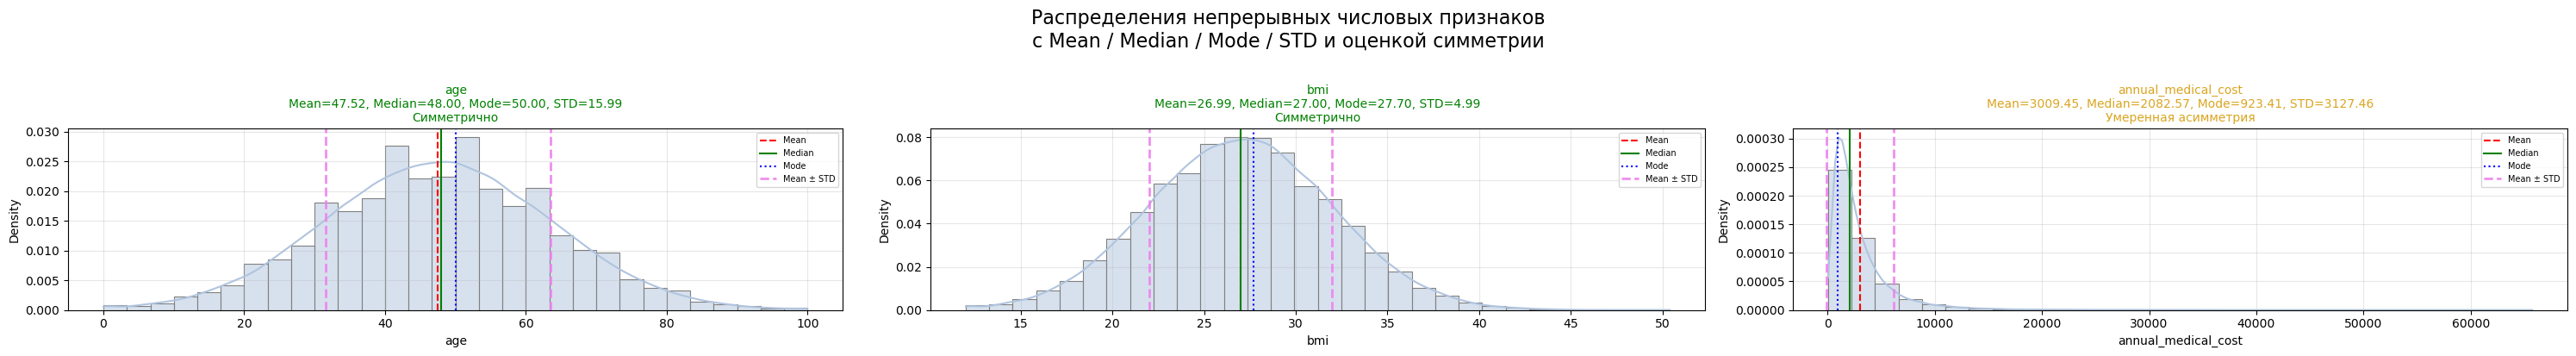

In [13]:
# Распределения непрерывных числовых признаков
# Смотрим форму распределения, среднее, медиану, моду и стандартное отклонение

plot_features = continuous_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10 * n_cols, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(plot_features):
    data = df[col].dropna()

    mean_val = data.mean()
    median_val = data.median()
    mode_val = data.mode().iloc[0] if not data.mode().empty else np.nan
    std_val = data.std()

    # Простая оценка асимметрии через разницу среднего и медианы
    diff = abs(mean_val - median_val)
    skew_ratio = diff / std_val if std_val != 0 else 0

    if skew_ratio < 0.1:
        color = 'green'
        label = 'Симметрично'
    elif skew_ratio < 0.3:
        color = 'goldenrod'
        label = 'Умеренная асимметрия'
    else:
        color = 'crimson'
        label = 'Сильная асимметрия'

    sns.histplot(
        data,
        bins=30,
        kde=True,
        color='lightsteelblue',
        edgecolor='gray',
        linewidth=0.8,
        ax=axes[i],
        stat='density'
    )

    # Основные статистики на графике
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')
    axes[i].axvline(mode_val, color='blue', linestyle=':', linewidth=1.5, label='Mode')

    # Интервал mean ± std
    axes[i].axvline(
        mean_val + std_val,
        color='violet',
        linestyle='--',
        linewidth=2,
        alpha=0.9,
        label='Mean ± STD'
    )
    axes[i].axvline(
        mean_val - std_val,
        color='violet',
        linestyle='--',
        linewidth=2,
        alpha=0.9
    )

    axes[i].set_title(
        (
            f'{col}\n'
            f'Mean={mean_val:.2f}, Median={median_val:.2f}, '
            f'Mode={mode_val:.2f}, STD={std_val:.2f}\n'
            f'{label}'
        ),
        fontsize=10,
        color=color
    )

    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=7)

# Удаляем пустые оси, если количество графиков не кратно n_cols
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределения непрерывных числовых признаков\n'
    'с Mean / Median / Mode / STD и оценкой симметрии',
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- `age` распределён близко к нормальному: основная масса пациентов находится в среднем возрастном диапазоне, явной асимметрии не наблюдается.

- `bmi` также имеет распределение, близкое к нормальному, с центром около 27.

- Целевая переменная `annual_medical_cost` имеет выраженный правый хвост: большинство пациентов имеют сравнительно небольшие расходы, но есть небольшая группа с очень высокими затратами.

- Среднее значение `annual_medical_cost` заметно выше медианы, что подтверждает положительную асимметрию распределения.

- Для моделирования это означает, что стоит отдельно следить за крупными ошибками на "дорогих" пациентах. Для линейных моделей можно рассмотреть логарифмирование таргета, а бустинговые модели, вероятно, будут лучше справляться с такой нелинейной структурой расходов.

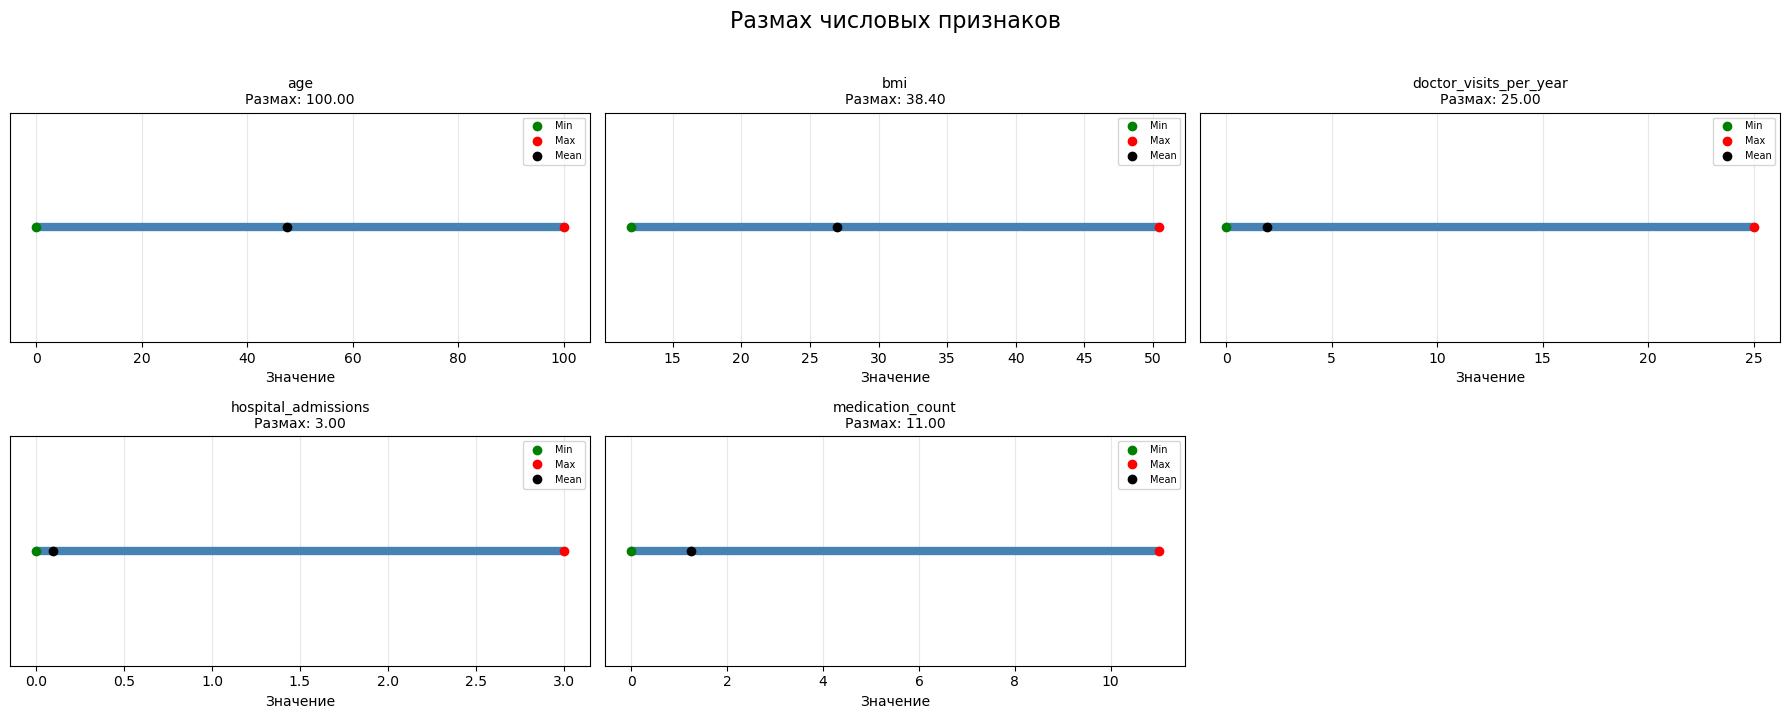

In [14]:
# Размах числовых признаков
# Смотрим минимальное, максимальное и среднее значение по каждому числовому признаку

plot_features = numeric_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 3.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    data = df[col].dropna()

    min_val = data.min()
    max_val = data.max()
    mean_val = data.mean()
    range_val = max_val - min_val

    # Линия от минимального до максимального значения
    axes[i].hlines(
        y=1,
        xmin=min_val,
        xmax=max_val,
        color='steelblue',
        linewidth=6
    )

    # Отмечаем min / max / mean
    axes[i].plot(min_val, 1, 'go', label='Min')
    axes[i].plot(max_val, 1, 'ro', label='Max')
    axes[i].plot(mean_val, 1, 'ko', label='Mean')

    axes[i].set_title(
        f'{col}\nРазмах: {range_val:.2f}',
        fontsize=10
    )

    axes[i].set_yticks([])
    axes[i].set_xlabel('Значение')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

# Удаляем пустые оси, если графиков меньше, чем ячеек сетки
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Размах числовых признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

- `age` принимает значения от 0 до 100 лет. Диапазон широкий, но выглядит допустимым для общего медицинского датасета.

- `bmi` находится в реалистичном диапазоне от 12.0 до 50.4. Явно некорректных экстремальных значений по min/max не видно.

- `doctor_visits_per_year` имеет размах от 0 до 25 визитов. Максимальные значения выглядят редкими, но потенциально возможными для пациентов с высокой медицинской нагрузкой.

- `hospital_admissions` принимает значения от 0 до 3. Большинство пациентов не имели госпитализаций, что видно по близости среднего значения к нулю.

- `medication_count` варьируется от 0 до 11. Высокие значения могут соответствовать пациентам с несколькими хроническими состояниями.

- В целом диапазоны признаков выглядят валидными. Для линейных моделей потребуется масштабирование, а для деревянных моделей признаки можно использовать без scaling.

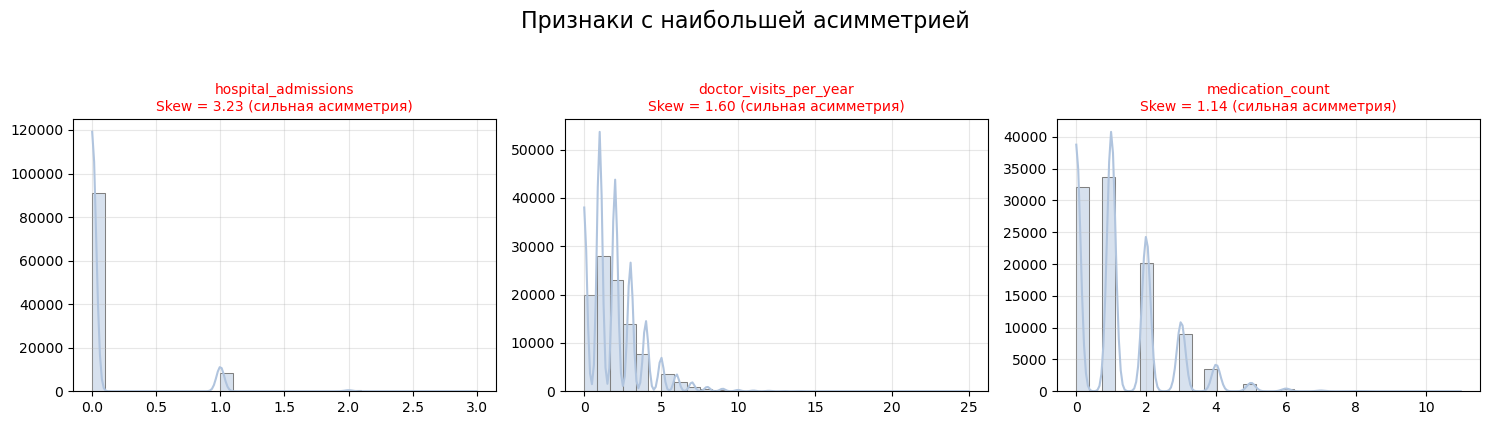

,skew
hospital_admissions,3.225
doctor_visits_per_year,1.598
medication_count,1.143


In [15]:
# Признаки с наибольшей асимметрией
# Ищем числовые признаки, распределение которых заметно отклоняется от симметричного

skew_threshold = 0.5
top_n = 4

# Считаем коэффициент асимметрии по числовым признакам
skew_values = df[numeric_features].skew()

# Оставляем признаки с заметной асимметрией
skewed_features = skew_values[skew_values.abs() > skew_threshold]

# Сортируем по абсолютной величине асимметрии
skewed_features = skewed_features.reindex(
    skewed_features.abs().sort_values(ascending=False).index
)

# Берём несколько наиболее "проблемных" признаков для визуализации
plot_features = skewed_features.head(top_n).index.tolist()

if len(plot_features) == 0:
    print(f'Признаков с |skew| > {skew_threshold} не найдено.')
else:
    fig, axes = plt.subplots(
        1,
        len(plot_features),
        figsize=(5 * len(plot_features), 4)
    )

    axes = np.atleast_1d(axes)

    for ax, col in zip(axes, plot_features):
        data = df[col].dropna()
        skew_val = data.skew()

        sns.histplot(
            data,
            bins=30,
            kde=True,
            ax=ax,
            color='lightsteelblue',
            edgecolor='gray'
        )

        # Оцениваем степень асимметрии
        if abs(skew_val) < 0.3:
            color = 'green'
            skew_label = 'симметричное'
        elif abs(skew_val) < 1:
            color = 'orange'
            skew_label = 'умеренная асимметрия'
        else:
            color = 'red'
            skew_label = 'сильная асимметрия'

        ax.set_title(
            f'{col}\nSkew = {skew_val:.2f} ({skew_label})',
            fontsize=10,
            color=color
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid(alpha=0.3)

    fig.suptitle('Признаки с наибольшей асимметрией', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Таблица со значениями асимметрии
skewed_features.to_frame(name='skew').round(3)

- Наибольшая асимметрия наблюдается у счётчиков медицинской нагрузки: `hospital_admissions`, `doctor_visits_per_year` и `medication_count`.

- Все три признака имеют выраженную положительную асимметрию: у большинства пациентов значения низкие, а высокие значения встречаются редко.

- `hospital_admissions` особенно сильно скошен вправо: подавляющее большинство пациентов не имели госпитализаций, а случаи с 1–3 госпитализациями встречаются заметно реже.

- `doctor_visits_per_year` и `medication_count` также имеют правый хвост, что соответствует ожидаемой структуре медицинских данных: небольшая доля пациентов потребляет значительно больше медицинских ресурсов.

- Для линейных моделей эти признаки можно рассмотреть как кандидаты на логарифмирование или другую трансформацию. Для деревянных моделей специальная обработка асимметрии обычно не требуется.

In [16]:
# Разделяем числовые признаки по степени асимметрии
# Это пригодится дальше для preprocessing pipeline линейных моделей

skew_threshold = 0.5

skew_values = df[numeric_features].skew()

numeric_skewed = skew_values[
    skew_values.abs() > skew_threshold
].index.tolist()

numeric_standard = [
    col for col in numeric_features
    if col not in numeric_skewed
]

print(f'Признаки с заметной асимметрией: {numeric_skewed}')
print(f'Остальные числовые признаки: {numeric_standard}')

Признаки с заметной асимметрией: ['doctor_visits_per_year', 'hospital_admissions', 'medication_count']
Остальные числовые признаки: ['age', 'bmi']


In [17]:
# Поиск потенциальных выбросов по IQR-методу
# Метод считает границы нормального диапазона: [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]

def get_iqr_outlier_info(data, column):
    values = data[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (values < lower_bound) | (values > upper_bound)
    outliers_count = outlier_mask.sum()

    return {
        'feature': column,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': outliers_count,
        'outliers_pct': outliers_count / len(values) * 100
    }


# Считаем информацию по всем числовым признакам
outliers_info = pd.DataFrame([
    get_iqr_outlier_info(df, col)
    for col in numeric_features
])

# Округляем числовые значения для более удобного отображения
outliers_info = outliers_info.round({
    'q1': 2,
    'q3': 2,
    'iqr': 2,
    'lower_bound': 2,
    'upper_bound': 2,
    'outliers_pct': 2
})

# Сортируем по доле потенциальных выбросов
outliers_info = outliers_info.sort_values(
    by='outliers_pct',
    ascending=False
)

outliers_info

,feature,q1,q3,iqr,lower_bound,upper_bound,outliers_count,outliers_pct
3,hospital_admissions,0.0,0.0,0.0,0.0,0.0,8969,8.97
2,doctor_visits_per_year,1.0,3.0,2.0,-2.0,6.0,2083,2.08
0,age,37.0,58.0,21.0,5.5,89.5,864,0.86
1,bmi,23.6,30.4,6.8,13.4,40.6,676,0.68
4,medication_count,0.0,2.0,2.0,-3.0,5.0,492,0.49


- IQR-метод отметил потенциальные выбросы во всех числовых признаках, но интерпретировать их нужно осторожно.

- Для `hospital_admissions` результат технически завышен: так как Q1 = Q3 = 0 и IQR = 0, любое значение выше 0 автоматически считается выбросом. На практике это не ошибка данных, а отражение того, что большинство пациентов не имели госпитализаций.

- У `doctor_visits_per_year` потенциальные выбросы начинаются выше 6 визитов в год. Такие значения могут быть редкими, но вполне реалистичными для пациентов с высокой медицинской нагрузкой.

- Для `age` значения выше 89.5 лет отмечаются как выбросы, но возраст 90+ является валидным для медицинского датасета и не должен автоматически удаляться.

- Для `bmi` значения ниже 13.4 и выше 40.6 отмечены как выбросы. В отличие от исходного датасета, диапазон BMI выглядит в целом реалистично, поэтому эти значения лучше оставить или отдельно проверить, но не удалять автоматически.

- Для `medication_count` значения выше 5 считаются выбросами по IQR, однако они могут быть валидными для пациентов с несколькими хроническими заболеваниями.

- На данном этапе выбросы не удаляем: большинство отмеченных значений выглядят медицински возможными и могут нести важную информацию о пациентах с высоким риском и высокими расходами.

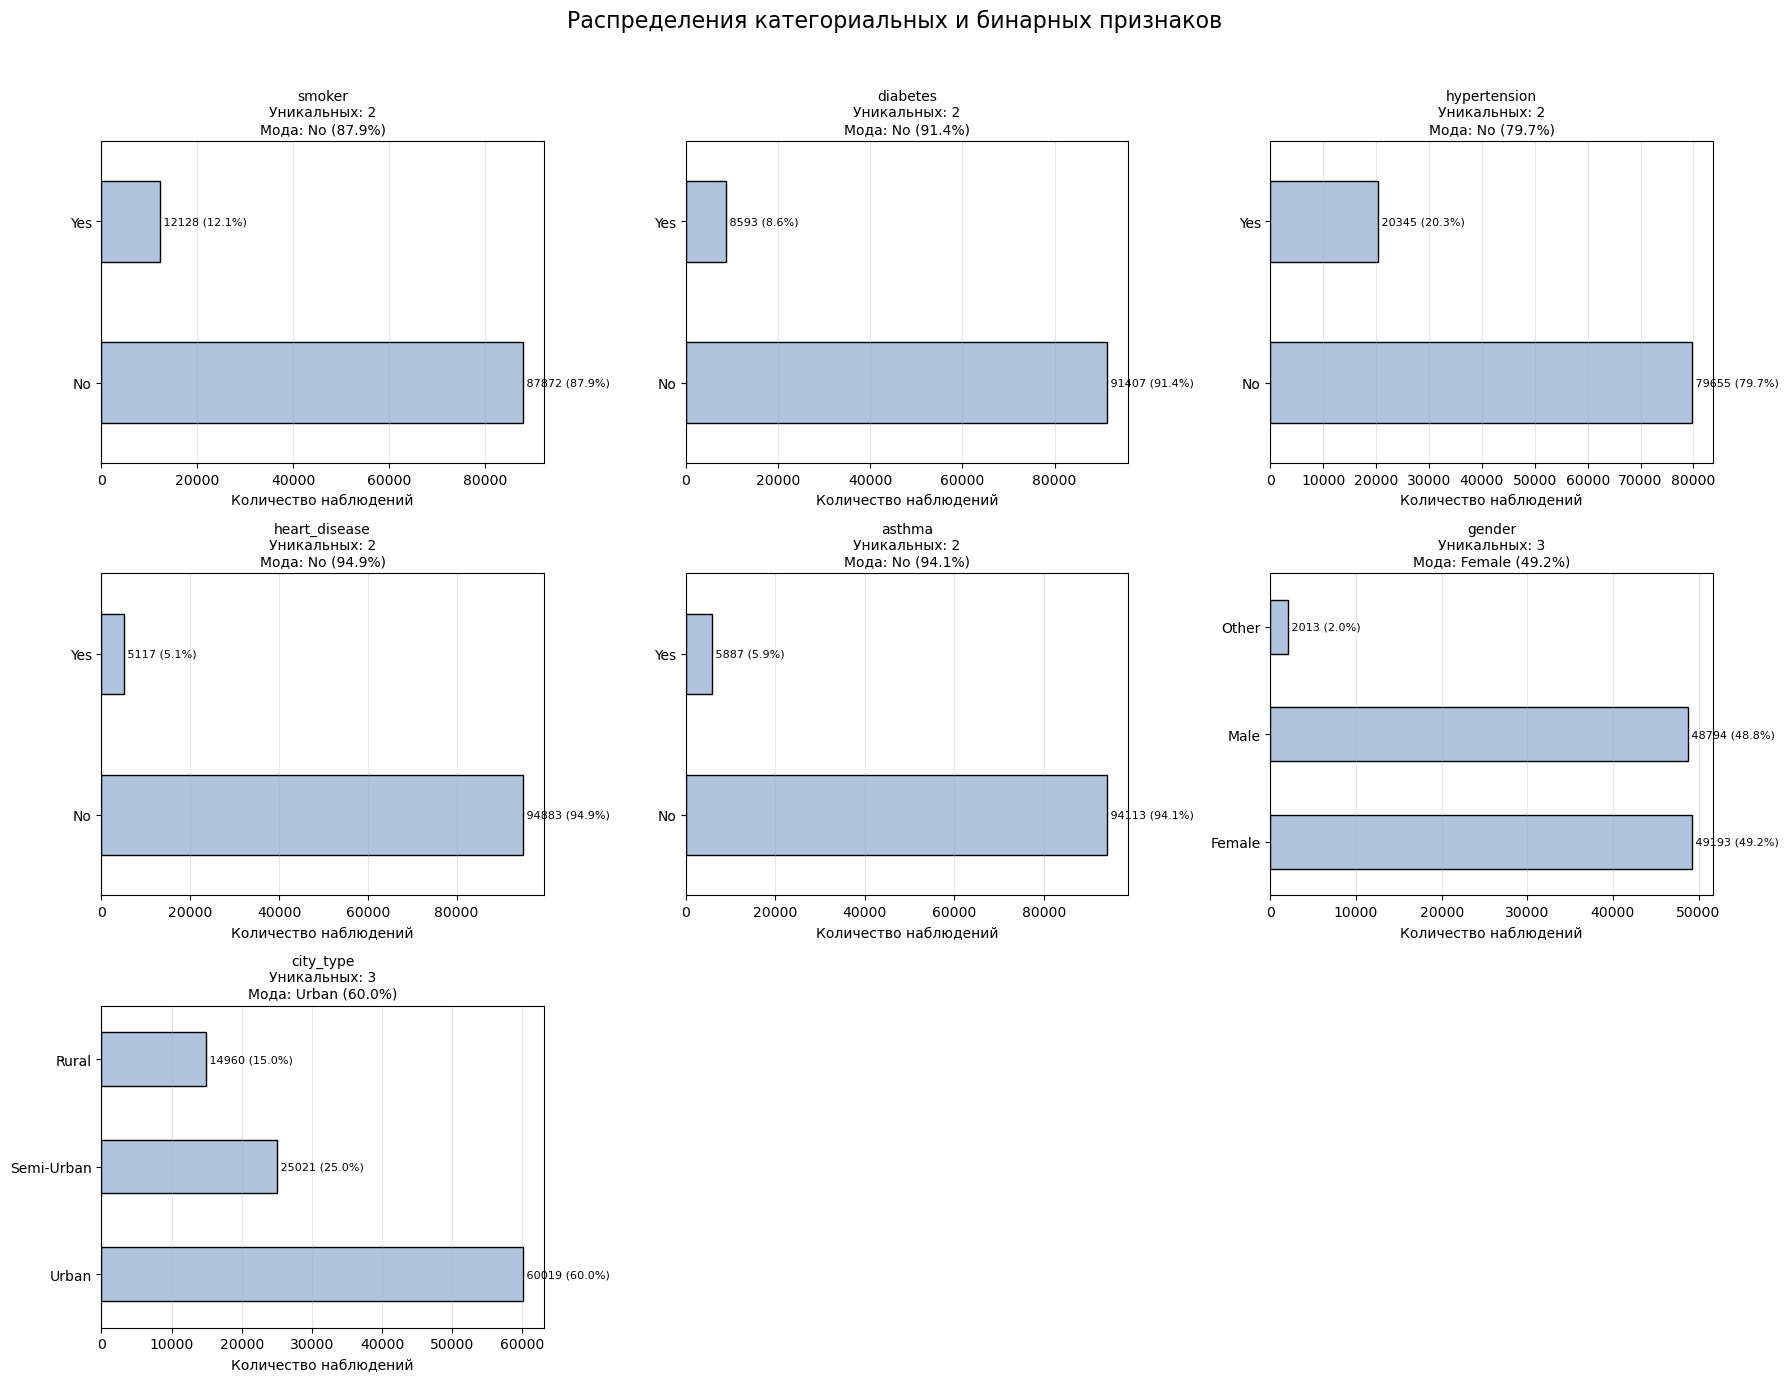

In [18]:
# Распределения категориальных и бинарных признаков
# Смотрим баланс категорий и долю самой частой категории

plot_features = cat_features_for_eda

# Читаемые подписи для бинарных признаков
binary_value_labels = {
    'smoker': {0: 'No', 1: 'Yes'},
    'diabetes': {0: 'No', 1: 'Yes'},
    'hypertension': {0: 'No', 1: 'Yes'},
    'heart_disease': {0: 'No', 1: 'Yes'},
    'asthma': {0: 'No', 1: 'Yes'}
}

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    # Для бинарных признаков заменяем 0/1 на понятные подписи
    if col in binary_value_labels:
        plot_data = df[col].map(binary_value_labels[col])
    else:
        plot_data = df[col]

    # Учитываем пропуски как отдельную категорию, если они есть
    plot_data = plot_data.fillna('Missing')

    counts = plot_data.value_counts()
    percents = counts / len(df) * 100

    counts.plot(
        kind='barh',
        color='lightsteelblue',
        edgecolor='black',
        ax=axes[i]
    )

    mode_val = counts.index[0]
    mode_percent = percents.iloc[0]

    axes[i].set_title(
        f'{col}\n'
        f'Уникальных: {plot_data.nunique()}\n'
        f'Мода: {mode_val} ({mode_percent:.1f}%)',
        fontsize=10
    )

    axes[i].set_xlabel('Количество наблюдений')
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', alpha=0.3)

    # Подписываем значения на барах
    for j, value in enumerate(counts):
        axes[i].text(
            value,
            j,
            f' {value} ({percents.iloc[j]:.1f}%)',
            va='center',
            fontsize=8
        )

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределения категориальных и бинарных признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- Среди бинарных медицинских признаков наблюдается выраженный дисбаланс: положительный класс встречается существенно реже отрицательного.

- Чаще всего среди заболеваний встречается `hypertension` — около 20.3% пациентов. Остальные состояния встречаются реже: `diabetes` — 8.6%, `asthma` — 5.9%, `heart_disease` — 5.1%.

- Доля курящих пациентов составляет около 12.1%, что делает признак `smoker` несбалансированным, но при этом достаточно представленным для моделирования.

- Признак `gender` почти сбалансирован между `Female` и `Male`, при этом категория `Other` составляет около 2% наблюдений. Её лучше оставить как отдельную категорию, а не удалять.

- В `city_type` преобладают городские пациенты: `Urban` — около 60%, `Semi-Urban` — 25%, `Rural` — 15%.

- В целом категориальные и бинарные признаки выглядят валидно: редких единичных категорий или очевидных ошибок в значениях не видно.

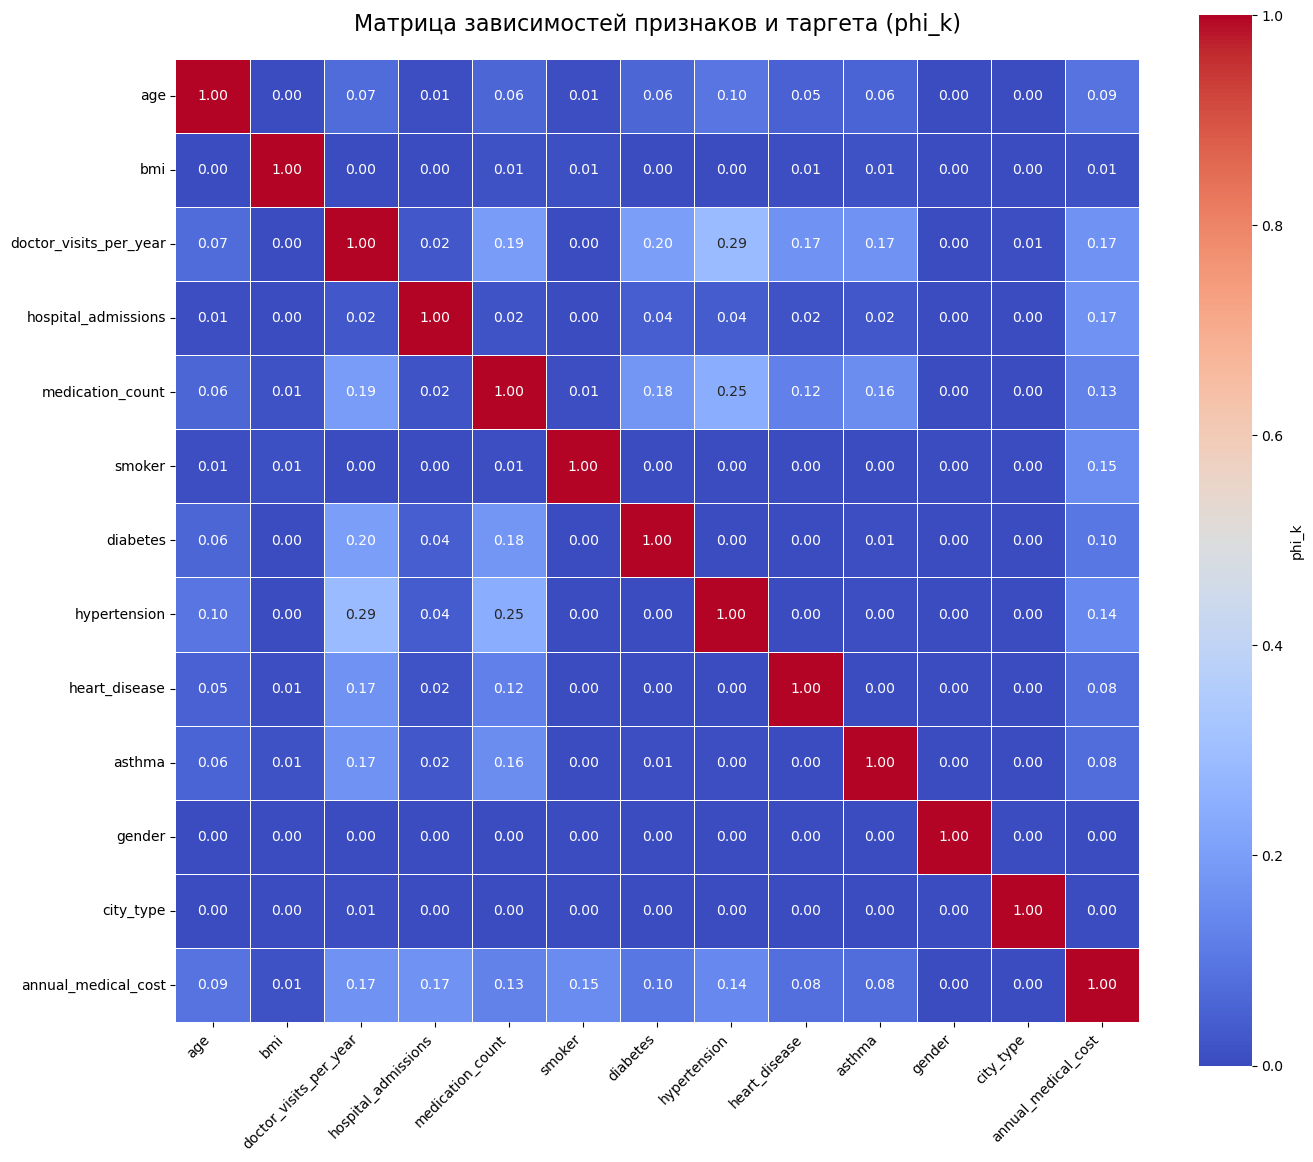

In [19]:
# Матрица зависимостей phi_k
# Позволяет оценивать связи между числовыми, бинарными и категориальными признаками,
# включая нелинейные зависимости

phik_features = feature_cols + [target_col]

phik_data = df[phik_features].copy()

# Бинарные признаки явно приводим к category,
# чтобы phi_k не интерпретировал их как непрерывные числовые признаки
for col in binary_features + categorical_features:
    phik_data[col] = phik_data[col].astype('category')

# Интервальными считаем только настоящие числовые признаки и таргет
interval_cols = numeric_features + [target_col]

phik_matrix = phik_data.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(14, 12))

sns.heatmap(
    phik_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'phi_k'}
)

plt.title('Матрица зависимостей признаков и таргета (phi_k)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- В отличие от исходного синтетического датасета, здесь нет одного явно доминирующего признака с очень высокой связью с таргетом.

- Наиболее заметную связь с `annual_medical_cost` показывают `doctor_visits_per_year` и `hospital_admissions` (`phi_k ≈ 0.17`), а также `smoker` (`phi_k ≈ 0.15`), `hypertension` (`phi_k ≈ 0.14`) и `medication_count` (`phi_k ≈ 0.13`).

- Связи с таргетом в целом умеренные или слабые, что говорит о более сложной структуре данных: расходы, вероятно, зависят не от одного признака, а от комбинации факторов.

- Между самими признаками есть ожидаемые умеренные связи: например, `doctor_visits_per_year` связан с `hypertension`, `diabetes`, `heart_disease`, `asthma` и `medication_count`, что отражает большую медицинскую нагрузку у пациентов с хроническими состояниями.

- `gender`, `city_type` и `bmi` почти не показывают самостоятельной связи с целевой переменной по phi_k.

- Для моделирования стоит сохранить все признаки: слабая индивидуальная связь не означает, что признак бесполезен в комбинации с другими переменными.

## 2. Анализ целевой переменной

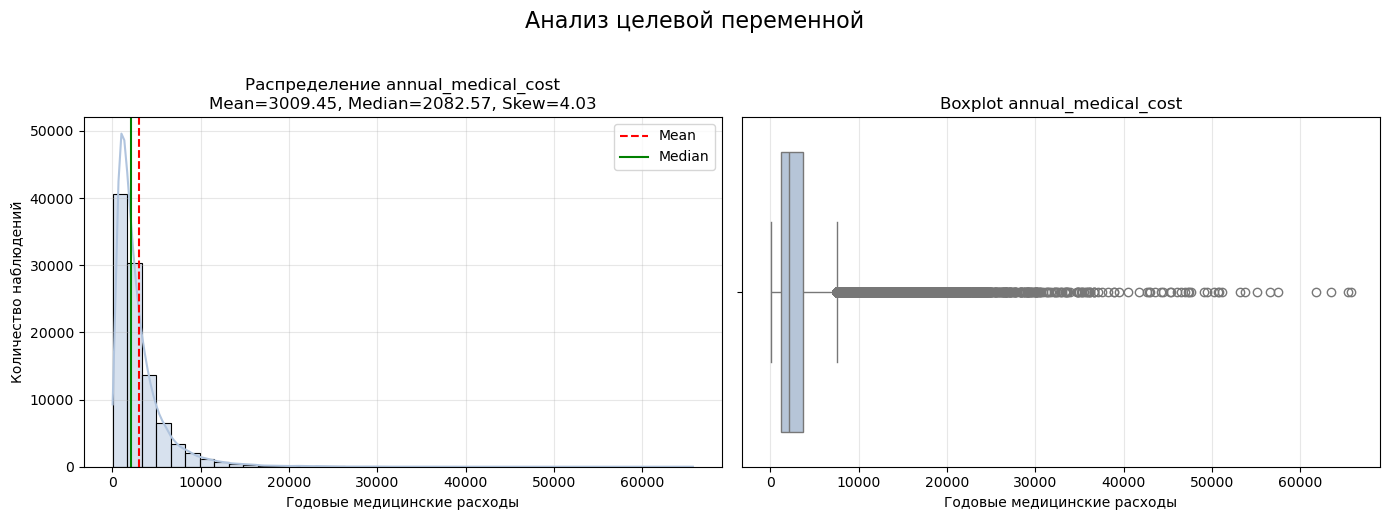

In [20]:
# Анализ распределения целевой переменной
# Смотрим форму распределения, асимметрию, основные статистики и возможные выбросы

target_data = df[target_col].dropna()

mean_val = target_data.mean()
median_val = target_data.median()
std_val = target_data.std()
skew_val = target_data.skew()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Распределение таргета
sns.histplot(
    target_data,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[0]
)

axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
axes[0].axvline(median_val, color='green', linestyle='-', linewidth=1.5, label='Median')

axes[0].set_title(
    f'Распределение {target_col}\n'
    f'Mean={mean_val:.2f}, Median={median_val:.2f}, Skew={skew_val:.2f}',
    fontsize=12
)
axes[0].set_xlabel('Годовые медицинские расходы')
axes[0].set_ylabel('Количество наблюдений')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot таргета
sns.boxplot(
    x=target_data,
    color='lightsteelblue',
    ax=axes[1]
)

axes[1].set_title(
    f'Boxplot {target_col}',
    fontsize=12
)
axes[1].set_xlabel('Годовые медицинские расходы')
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle(
    'Анализ целевой переменной',
    fontsize=16,
    y=1.03
)

plt.tight_layout()
plt.show()

In [21]:
# Краткая статистика по целевой переменной

target_summary = pd.DataFrame({
    'count': [target_data.count()],
    'mean': [target_data.mean()],
    'median': [target_data.median()],
    'std': [target_data.std()],
    'min': [target_data.min()],
    'max': [target_data.max()],
    'skew': [target_data.skew()]
})

target_summary.round(2)

,count,mean,median,std,min,max,skew
0,100000,3009.45,2082.57,3127.46,55.55,65724.9,4.03


- Целевая переменная `annual_medical_cost` имеет выраженную правостороннюю асимметрию: большинство пациентов имеют сравнительно небольшие расходы, но есть длинный хвост пациентов с очень высокими затратами.

- Среднее значение расходов заметно выше медианы: около 3009 против 2083. Это подтверждает, что небольшая доля дорогих пациентов сильно влияет на среднее.

- Коэффициент асимметрии высокий (`skew = 4.03`), поэтому распределение таргета существенно отличается от нормального.

- На boxplot видно большое количество верхних выбросов. Для медицинских расходов это ожидаемо: отдельные пациенты могут иметь редкие, но очень дорогие случаи лечения.

- Автоматически удалять такие наблюдения не стоит, так как именно дорогие пациенты важны для задачи прогнозирования расходов.

- Для линейных моделей стоит рассмотреть логарифмирование таргета через `TransformedTargetRegressor`, а для деревянных моделей и бустингов таргет можно оставить в исходном масштабе.

In [22]:
# Оцениваем связь каждого признака с целевой переменной
# Используем phi_k, так как он умеет учитывать числовые, бинарные,
# категориальные и потенциально нелинейные зависимости

phik_features = feature_cols + [target_col]

phik_data = df[phik_features].copy()

# Бинарные и категориальные признаки явно приводим к category
for col in binary_features + categorical_features:
    phik_data[col] = phik_data[col].astype('category')

# Интервальными считаем только настоящие числовые признаки и таргет
interval_cols = numeric_features + [target_col]

phik_matrix = phik_data.phik_matrix(interval_cols=interval_cols)

# Достаём связи признаков с таргетом и убираем сам таргет
target_phik = (
    phik_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

target_phik.round(3)

doctor_visits_per_year    0.170
hospital_admissions       0.169
smoker                    0.151
hypertension              0.143
medication_count          0.126
diabetes                  0.100
age                       0.093
heart_disease             0.079
asthma                    0.076
bmi                       0.015
gender                    0.000
city_type                 0.000
Name: annual_medical_cost, dtype: float64

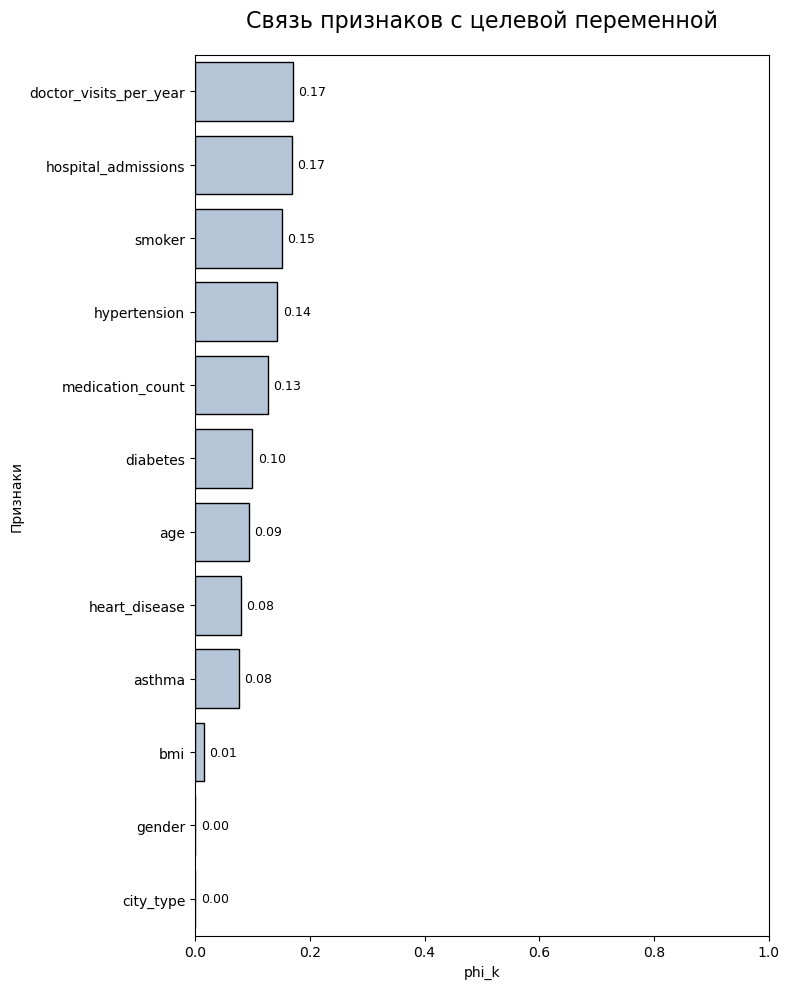

In [23]:
# Связь признаков с целевой переменной

target_phik = (
    phik_matrix[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 10))

ax = sns.barplot(
    x=target_phik.values,
    y=target_phik.index,
    orient='h',
    color='lightsteelblue',
    edgecolor='black'
)

ax.set_title(
    'Связь признаков с целевой переменной',
    fontsize=16,
    pad=20
)
ax.set_xlabel('phi_k')
ax.set_ylabel('Признаки')
ax.set_xlim(0, 1)

# Подписываем значения на барах
for i, value in enumerate(target_phik.values):
    ax.text(
        value + 0.01,
        i,
        f'{value:.2f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

- Наиболее заметную связь с целевой переменной показывают признаки медицинской нагрузки: `doctor_visits_per_year` и `hospital_admissions` (`phi_k ≈ 0.17`).

- Также умеренная связь с расходами есть у `smoker`, `hypertension`, `medication_count` и `diabetes`.

- В отличие от исходного синтетического датасета, здесь нет одного доминирующего признака, который почти полностью объясняет таргет.

- Значения `phi_k` в целом невысокие, поэтому задача выглядит сложнее: расходы зависят от комбинации факторов, а не от одной сильной переменной.

- `bmi`, `gender` и `city_type` почти не показывают самостоятельной связи с таргетом по phi_k.

- Для моделирования стоит сохранить все признаки: даже слабые признаки могут быть полезны в нелинейных моделях и во взаимодействии с другими переменными.

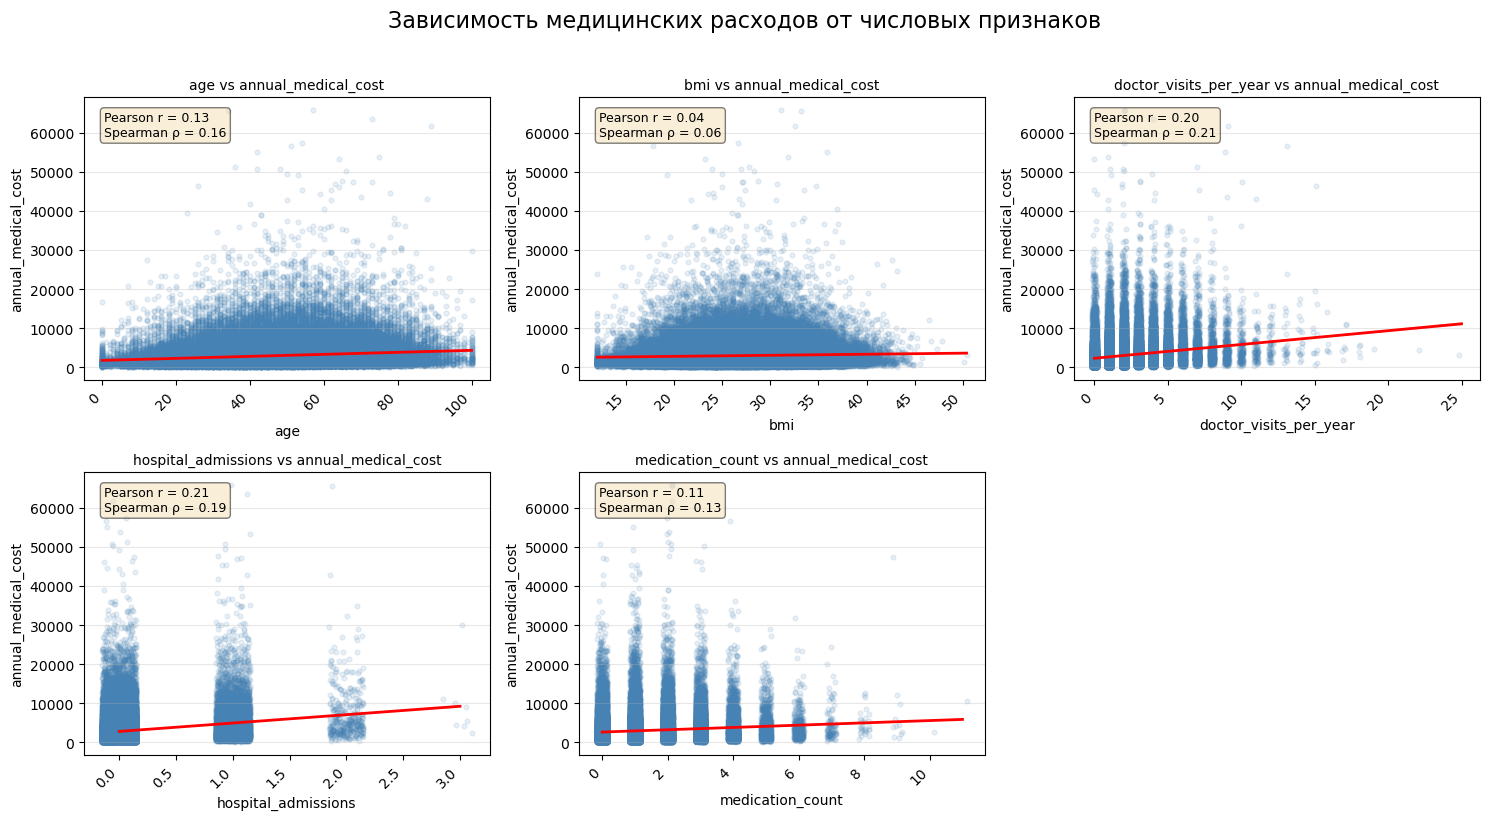

In [24]:
# Связь числовых признаков с целевой переменной
# Смотрим scatterplot + линейный тренд, а также Pearson и Spearman корреляции

plot_features = numeric_features

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, feature in enumerate(plot_features):
    ax = axes[i]

    # Для дискретных признаков добавляем небольшой jitter,
    # чтобы точки не накладывались строго друг на друга
    x_jitter = 0.15 if feature in count_features else None

    sns.regplot(
        data=df,
        x=feature,
        y=target_col,
        scatter_kws={
            'alpha': 0.12,
            's': 12,
            'color': 'steelblue'
        },
        line_kws={
            'color': 'red',
            'linewidth': 2
        },
        x_jitter=x_jitter,
        ax=ax
    )

    pearson_corr = df[[feature, target_col]].corr(method='pearson').iloc[0, 1]
    spearman_corr = df[[feature, target_col]].corr(method='spearman').iloc[0, 1]

    ax.text(
        0.05,
        0.95,
        f'Pearson r = {pearson_corr:.2f}\nSpearman ρ = {spearman_corr:.2f}',
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.5
        )
    )

    ax.set_title(
        f'{feature} vs {target_col}',
        fontsize=10
    )
    ax.set_xlabel(feature)
    ax.set_ylabel(target_col)
    ax.grid(axis='y', alpha=0.3)

    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Зависимость медицинских расходов от числовых признаков',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- Все числовые признаки показывают положительную связь с `annual_medical_cost`, но связи в целом слабые или умеренные.

- Наиболее выраженная линейная связь наблюдается у `hospital_admissions` и `doctor_visits_per_year`: чем больше госпитализаций и визитов к врачу, тем выше ожидаемые медицинские расходы.

- `age` также имеет слабую положительную связь с расходами: у более возрастных пациентов расходы в среднем немного выше.

- `medication_count` связан с расходами положительно, но умеренно: большее количество лекарств может отражать более высокую медицинскую нагрузку.

- `bmi` почти не показывает выраженной линейной или монотонной зависимости с таргетом.

- На всех графиках заметен широкий разброс значений и большое количество пациентов с высокими расходами, поэтому задача выглядит заметно сложнее, чем на исходном синтетическом датасете.

- Низкие корреляции не означают, что признаки бесполезны: их вклад может проявляться через нелинейности и взаимодействия, которые лучше улавливают бустинговые и ансамблевые модели.

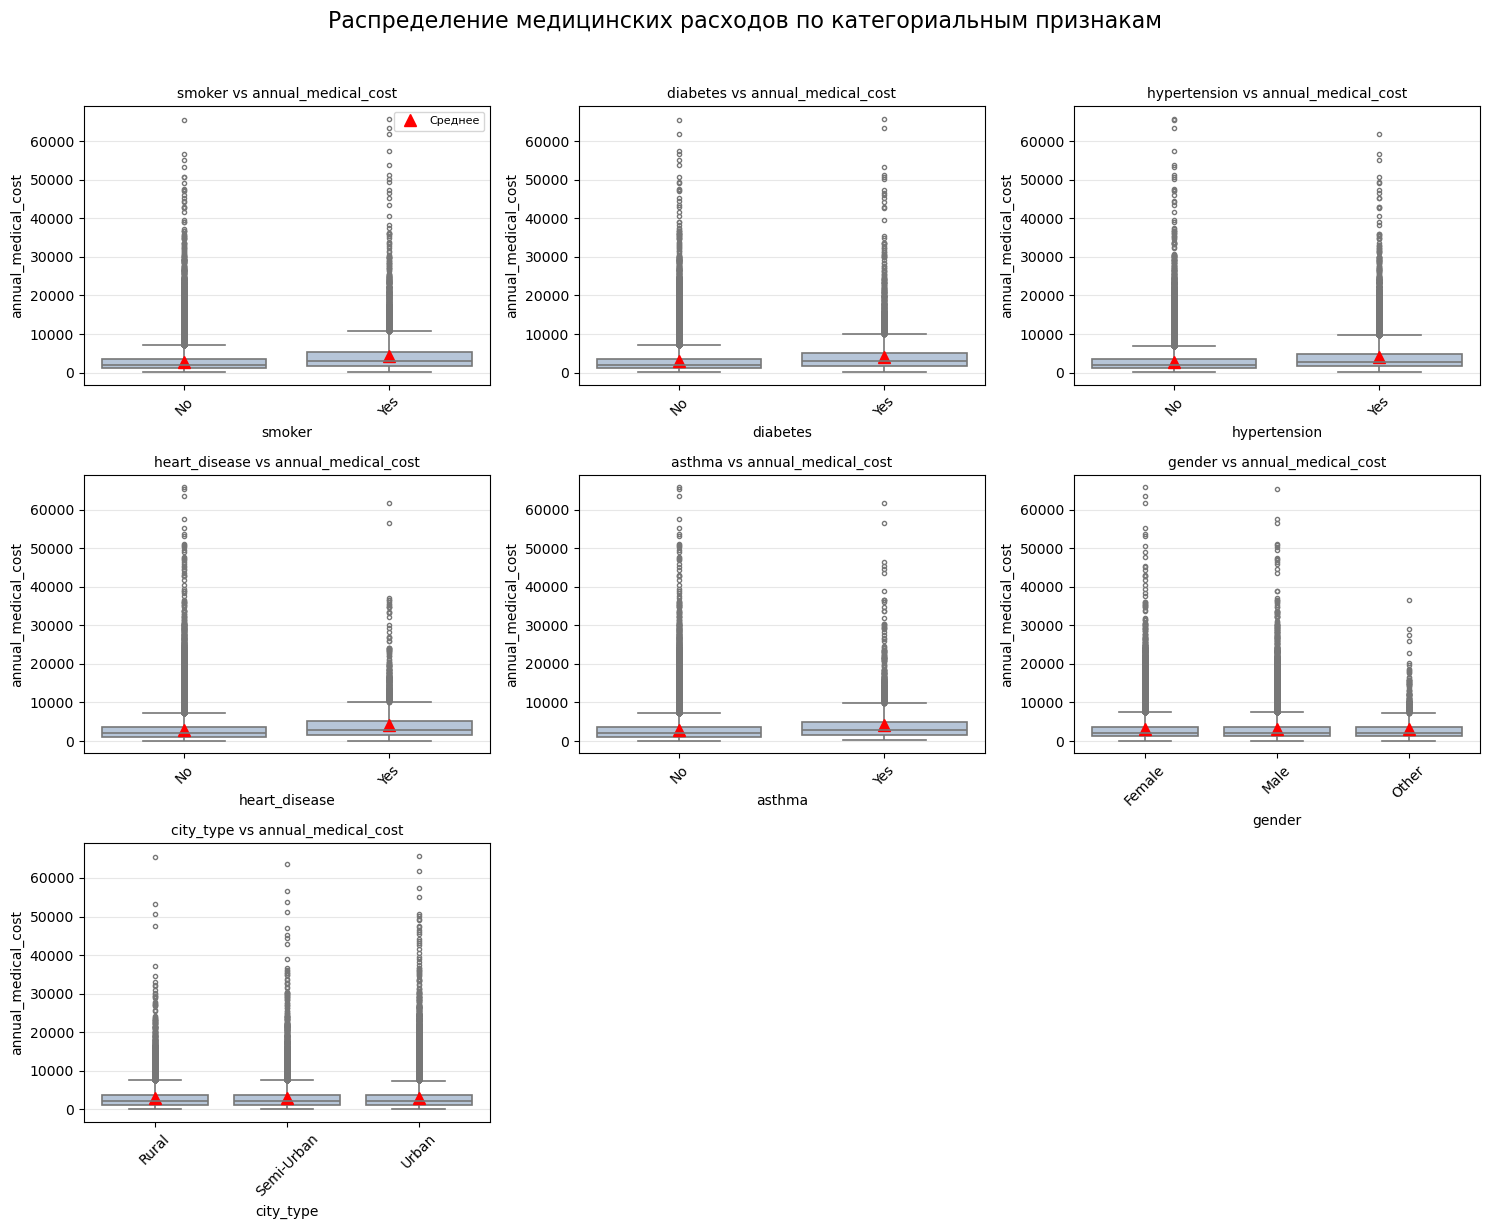

In [26]:
# Зависимость целевой переменной от категориальных и бинарных признаков
# Смотрим, как распределяются медицинские расходы в разных категориях признаков

plot_features = cat_features_for_eda

# Копия датафрейма только для визуализации
plot_df = df.copy()

# Читаемые подписи для бинарных признаков
binary_value_labels = {
    'smoker': {0: 'No', 1: 'Yes'},
    'diabetes': {0: 'No', 1: 'Yes'},
    'hypertension': {0: 'No', 1: 'Yes'},
    'heart_disease': {0: 'No', 1: 'Yes'},
    'asthma': {0: 'No', 1: 'Yes'}
}

# Заменяем 0/1 на текстовые категории только для графиков
for col, mapping in binary_value_labels.items():
    plot_df[col] = plot_df[col].map(mapping)

n_cols = 3
n_rows = (len(plot_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(plot_features):
    ax = axes[i]

    # Учитываем пропуски как отдельную категорию, если они есть
    plot_df[col] = plot_df[col].fillna('Missing')

    # Средние значения таргета по категориям
    means = plot_df.groupby(col, observed=False)[target_col].mean()

    # Порядок категорий на графике
    order = means.index.tolist()

    sns.boxplot(
        data=plot_df,
        x=col,
        y=target_col,
        order=order,
        color='lightsteelblue',
        fliersize=3,
        linewidth=1.2,
        ax=ax
    )

    # Отмечаем среднее значение таргета по каждой категории
    for j, category in enumerate(order):
        ax.plot(
            j,
            means.loc[category],
            'r^',
            markersize=8,
            label='Среднее' if j == 0 else ''
        )

    ax.set_title(f'{col} vs {target_col}', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# Удаляем пустые оси
for j in range(len(plot_features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Распределение медицинских расходов по категориальным признакам',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

- Для большинства медицинских бинарных признаков группа `Yes` имеет более высокие средние и медианные расходы, чем группа `No`.

- Наиболее заметное смещение расходов вверх видно у пациентов со статусом `smoker = Yes`, а также у пациентов с `diabetes`, `hypertension`, `heart_disease` и `asthma`.

- Различия между группами есть, но распределения сильно перекрываются. Это означает, что один категориальный признак сам по себе не объясняет расходы полностью.

- Для `gender` заметных различий между `Female`, `Male` и `Other` не наблюдается. Этот признак, вероятно, будет иметь слабый вклад в модель.

- Для `city_type` распределения расходов также очень похожи между категориями `Rural`, `Semi-Urban` и `Urban`.

- Во всех группах присутствуют верхние выбросы по медицинским расходам, что подтверждает наличие небольшой доли пациентов с очень высокими затратами.

- В целом графики подтверждают, что расходы выше у пациентов с хроническими заболеваниями и факторами риска, но задача требует модели, учитывающей комбинации признаков и нелинейные зависимости.

## Общие выводы по EDA

- Новый датасет содержит 100 000 наблюдений и выглядит более сложным, чем исходный синтетический датасет: целевая переменная имеет сильную правостороннюю асимметрию и большое количество дорогих пациентов.

- `annual_medical_cost` заметно отличается от нормального распределения: среднее существенно выше медианы, а коэффициент асимметрии высокий. Это важно учитывать при выборе метрик и моделей.

- Большинство числовых признаков имеют реалистичные диапазоны значений. Выбросы по IQR в основном соответствуют редким, но возможным медицинским случаям, поэтому автоматически удалять их не стоит.

- Самые асимметричные признаки — `hospital_admissions`, `doctor_visits_per_year` и `medication_count`. Это ожидаемо: у большинства пациентов медицинская нагрузка небольшая, но есть небольшая группа пациентов с большим числом визитов, госпитализаций и лекарств.

- Бинарные медицинские признаки несбалансированы: хронические заболевания и факторы риска встречаются у меньшей части пациентов, но именно эти группы в среднем имеют более высокие расходы.

- Наиболее заметную связь с таргетом показывают признаки медицинской нагрузки и состояния здоровья: `doctor_visits_per_year`, `hospital_admissions`, `smoker`, `hypertension`, `medication_count` и `diabetes`.

- `gender`, `city_type` и `bmi` почти не показывают самостоятельной связи с целевой переменной, но их всё равно стоит оставить в модели, так как эффект может проявляться во взаимодействии с другими признаками.

- В отличие от исходного синтетического датасета, здесь нет одного доминирующего признака, который почти полностью объясняет таргет. Задача выглядит более реалистичной и требует моделей, способных учитывать нелинейности и комбинации факторов.

- Для дальнейшего моделирования стоит сохранить все выбранные признаки, использовать кросс-валидацию, а также сравнить линейные модели, бустинги и ансамбли на едином фиксированном test-наборе.

# ML-моделирование


В этом разделе переходим к построению моделей и ансамблей.  
Сначала фиксируем train/test split, группы признаков, стратегию кросс-валидации и общие функции для оценки качества.

Test set откладывается до самого конца и не используется ни для подбора гиперпараметров, ни для расчёта весов ансамблей.  
Вся промежуточная оценка моделей выполняется внутри train через cross-validation и out-of-fold predictions.

In [77]:
# Базовые настройки эксперимента

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

np.random.seed(RANDOM_STATE)

In [78]:
# Фиксируем целевую переменную и группы признаков

target_col = 'annual_medical_cost'
id_col = 'person_id'

numeric_features = [
    'age',
    'bmi',
    'doctor_visits_per_year',
    'hospital_admissions',
    'medication_count'
]

binary_features = [
    'smoker',
    'diabetes',
    'hypertension',
    'heart_disease',
    'asthma'
]

# gender оставляем категориальным, так как в новом датасете есть категория Other
categorical_features = [
    'gender',
    'city_type'
]

feature_cols = numeric_features + binary_features + categorical_features

# Проверяем наличие нужных колонок

required_cols = feature_cols + [target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

assert len(missing_cols) == 0, f'В df отсутствуют колонки: {missing_cols}'
assert df[target_col].isna().sum() == 0, 'В целевой переменной есть пропуски'

In [79]:
# Формируем X и y
# person_id не используем как признак

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (100000, 12)
y shape: (100000,)


In [80]:
# Делаем стратификацию по бинам таргета,
# чтобы сохранить похожее распределение annual_medical_cost в train и test

target_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

# Сбрасываем индексы, чтобы дальше удобно работать с OOF/test predictions
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')

Train shape: (80000, 12)
Test shape:  (20000, 12)


In [81]:
# Проверяем, что распределение таргета в train и test похоже

def get_target_summary(y_values, name):
    return pd.Series({
        'count': y_values.count(),
        'mean': y_values.mean(),
        'median': y_values.median(),
        'std': y_values.std(),
        'min': y_values.min(),
        'max': y_values.max(),
        'skew': y_values.skew()
    }, name=name)


target_split_summary = pd.concat(
    [
        get_target_summary(y_train, 'train'),
        get_target_summary(y_test, 'test')
    ],
    axis=1
)

target_split_summary.round(2)

,train,test
count,80000.00,20000.00
mean,3011.43,3001.54
median,2082.54,2082.76
std,3139.55,3078.69
min,55.55,57.85
max,65724.90,56596.07
skew,4.08,3.81


In [82]:
# Выделяем числовые признаки с заметной асимметрией.
# Это пригодится для preprocessing pipeline линейных моделей.

skew_threshold = 0.5

train_skew_values = X_train[numeric_features].skew()

numeric_skewed = train_skew_values[
    train_skew_values.abs() > skew_threshold
].index.tolist()

numeric_standard = [
    col for col in numeric_features
    if col not in numeric_skewed
]

print(f'Признаки с заметной асимметрией: {numeric_skewed}')
print(f'Остальные числовые признаки: {numeric_standard}')

Признаки с заметной асимметрией: ['doctor_visits_per_year', 'hospital_admissions', 'medication_count']
Остальные числовые признаки: ['age', 'bmi']


In [83]:
# Стратегия кросс-валидации

cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [84]:
# Метрики для оценки моделей.
# Основная метрика — MAE, так как она интерпретируется в денежных единицах.

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'r2': 'r2',
    'mape': 'neg_mean_absolute_percentage_error'
}

refit_metric = 'mae'

In [85]:
# Helper-функция для расчёта метрик на одном наборе данных

def calculate_regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

# Helper-функция для оценки модели на кросс-валидации

def cross_validate_regression_model(
    model,
    X,
    y,
    model_name,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=False
    )

    result = {
        'model': model_name,
        'CV_MAE_mean': -cv_results['test_mae'].mean(),
        'CV_MAE_std': (-cv_results['test_mae']).std(),
        'CV_RMSE_mean': -cv_results['test_rmse'].mean(),
        'CV_RMSE_std': (-cv_results['test_rmse']).std(),
        'CV_R2_mean': cv_results['test_r2'].mean(),
        'CV_R2_std': cv_results['test_r2'].std(),
        'CV_MAPE_mean': -cv_results['test_mape'].mean(),
        'CV_MAPE_std': (-cv_results['test_mape']).std()
    }

    return pd.Series(result)


# Helper-функция для финальной оценки уже обученной модели на test.
# Test будем использовать только в самом конце исследования.

def evaluate_on_test(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics['model'] = model_name

    metrics = {
        'model': metrics.pop('model'),
        **metrics
    }

    return pd.Series(metrics), y_pred

In [86]:
# Контейнеры для результатов

cv_results = []
test_results = []
test_predictions = {}

## 1. Линейные модели

В качестве линейного baseline обучаем три регуляризованные модели:

- `Ridge` — L2-регуляризация;
- `Lasso` — L1-регуляризация;
- `ElasticNet` — комбинация L1 и L2.

Для линейных моделей используем отдельный preprocessing pipeline: числовые признаки масштабируются, асимметричные счётчики дополнительно логарифмируются, бинарные признаки остаются в формате 0/1, а категориальные признаки кодируются через one-hot encoding.

In [87]:
# Preprocessing для линейных моделей

def make_linear_preprocessor(
    numeric_standard,
    numeric_skewed,
    binary_features,
    categorical_features
):
    transformers = []

    if len(numeric_standard) > 0:
        standard_numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])

        transformers.append(
            ('num_standard', standard_numeric_pipeline, numeric_standard)
        )

    if len(numeric_skewed) > 0:
        skewed_numeric_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scaler', StandardScaler())
        ])

        transformers.append(
            ('num_skewed', skewed_numeric_pipeline, numeric_skewed)
        )

    if len(binary_features) > 0:
        binary_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent'))
        ])

        transformers.append(
            ('binary', binary_pipeline, binary_features)
        )

    if len(categorical_features) > 0:
        # Явно задаём базовые категории:
        # gender: Other
        # city_type: Rural
        categorical_drop_map = {
            'gender': 'Other',
            'city_type': 'Rural'
        }

        categorical_drop = [
            categorical_drop_map[col]
            for col in categorical_features
        ]

        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(
                drop=categorical_drop,
                handle_unknown='ignore',
                sparse_output=False
            ))
        ])

        transformers.append(
            ('cat', categorical_pipeline, categorical_features)
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        verbose_feature_names_out=True
    )


# Собираем pipeline для линейных моделей

def make_linear_pipeline(model):
    linear_preprocessor = make_linear_preprocessor(
        numeric_standard=numeric_standard,
        numeric_skewed=numeric_skewed,
        binary_features=binary_features,
        categorical_features=categorical_features
    )

    target_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    return Pipeline([
        ('preprocessor', linear_preprocessor),
        ('model', target_model)
    ])


# Helper-функция для запуска GridSearchCV

def run_grid_search(model_name, pipeline, param_grid):
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit='mae',
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f'{model_name}')
    print(f'Best CV MAE: {-search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')
    print()

    return search


# Helper-функция для извлечения метрик лучшей модели из GridSearchCV

def get_best_grid_metrics(search, model_name):
    best_idx = search.best_index_

    return pd.Series({
        'model': model_name,
        'CV_MAE_mean': -search.cv_results_['mean_test_mae'][best_idx],
        'CV_MAE_std': search.cv_results_['std_test_mae'][best_idx],
        'CV_RMSE_mean': -search.cv_results_['mean_test_rmse'][best_idx],
        'CV_RMSE_std': search.cv_results_['std_test_rmse'][best_idx],
        'CV_R2_mean': search.cv_results_['mean_test_r2'][best_idx],
        'CV_R2_std': search.cv_results_['std_test_r2'][best_idx],
        'CV_MAPE_mean': -search.cv_results_['mean_test_mape'][best_idx],
        'CV_MAPE_std': search.cv_results_['std_test_mape'][best_idx]
    })

### Ridge Regression

In [88]:
# Ridge Regression

ridge_pipeline = make_linear_pipeline(
    Ridge(random_state=RANDOM_STATE)
)

ridge_param_grid = {
    'model__regressor__alpha': np.logspace(-3, 4, 12)
}

ridge_search = run_grid_search(
    model_name='Ridge',
    pipeline=ridge_pipeline,
    param_grid=ridge_param_grid
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Ridge
Best CV MAE: 1692.6990
Best params: {'model__regressor__alpha': 533.6699231206312}



### Lasso Regression

In [89]:
# Lasso Regression

lasso_pipeline = make_linear_pipeline(
    Lasso(
        max_iter=50_000,
        random_state=RANDOM_STATE
    )
)

lasso_param_grid = {
    'model__regressor__alpha': np.logspace(-4, 2, 12)
}

lasso_search = run_grid_search(
    model_name='Lasso',
    pipeline=lasso_pipeline,
    param_grid=lasso_param_grid
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Lasso
Best CV MAE: 1692.6691
Best params: {'model__regressor__alpha': 0.0012328467394420659}



### ElasticNet Regression

In [90]:
# ElasticNet Regression

elasticnet_pipeline = make_linear_pipeline(
    ElasticNet(
        max_iter=50_000,
        random_state=RANDOM_STATE
    )
)

elasticnet_param_grid = {
    'model__regressor__alpha': np.logspace(-4, 2, 10),
    'model__regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_search = run_grid_search(
    model_name='ElasticNet',
    pipeline=elasticnet_pipeline,
    param_grid=elasticnet_param_grid
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
ElasticNet
Best CV MAE: 1692.6039
Best params: {'model__regressor__alpha': 0.002154434690031882, 'model__regressor__l1_ratio': 0.9}



### Результаты линейных моделей

In [91]:
# Собираем CV-результаты линейных моделей

linear_cv_results = pd.DataFrame([
    get_best_grid_metrics(ridge_search, 'Ridge'),
    get_best_grid_metrics(lasso_search, 'Lasso'),
    get_best_grid_metrics(elasticnet_search, 'ElasticNet')
])

linear_cv_results = linear_cv_results.sort_values(
    by='CV_MAE_mean',
    ascending=True
).reset_index(drop=True)

linear_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,ElasticNet,1692.6039,12.8485,3029.8706,36.2506,0.0685,0.0077,0.7597,0.0095
1,Lasso,1692.6691,12.7949,3027.8263,36.1395,0.0697,0.0078,0.7596,0.0094
2,Ridge,1692.6990,12.9366,3030.0800,36.3996,0.0683,0.0077,0.7598,0.0094


In [92]:
# Сохраняем fitted-модели.
# GridSearchCV уже обучил best_estimator_ на всём train.

linear_fitted_models = {
    'Ridge': ridge_search.best_estimator_,
    'Lasso': lasso_search.best_estimator_,
    'ElasticNet': elasticnet_search.best_estimator_
}

best_linear_name = linear_cv_results.loc[0, 'model']
best_linear_model = linear_fitted_models[best_linear_name]

print(f'Лучшая линейная модель по CV MAE: {best_linear_name}')

Лучшая линейная модель по CV MAE: ElasticNet


In [93]:
# Добавляем результаты линейных моделей в общий список CV-результатов

cv_results.extend(linear_cv_results.to_dict('records'))

### Анализ feature importance для линейных моделей

In [94]:
# Функции для извлечения коэффициентов линейной модели после preprocessing

def clean_transformed_feature_name(feature_name):
    return feature_name.split('__', 1)[-1]


def get_original_feature_name(transformed_feature_name, original_features):
    clean_name = clean_transformed_feature_name(transformed_feature_name)

    for feature in sorted(original_features, key=len, reverse=True):
        if clean_name == feature or clean_name.startswith(f'{feature}_'):
            return feature

    return clean_name


def get_linear_coefficients(fitted_pipeline):
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()

    target_model = fitted_pipeline.named_steps['model']
    model = target_model.regressor_

    coef_df = pd.DataFrame({
        'feature': [clean_transformed_feature_name(name) for name in feature_names],
        'original_feature': [
            get_original_feature_name(name, feature_cols)
            for name in feature_names
        ],
        'coefficient': model.coef_
    })

    coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

    return coef_df.sort_values(
        by='abs_coefficient',
        ascending=False
    ).reset_index(drop=True)

In [95]:
# Проверяем базовые категории one-hot encoding

cat_encoder = (
    best_linear_model
    .named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
)

for feature, categories, dropped in zip(
    categorical_features,
    cat_encoder.categories_,
    cat_encoder.drop_idx_
):
    print(f'{feature}:')
    print(f'  категории: {list(categories)}')
    print(f'  базовая категория: {categories[dropped]}')
    print()

gender:
  категории: ['Female', 'Male', 'Other']
  базовая категория: Other

city_type:
  категории: ['Rural', 'Semi-Urban', 'Urban']
  базовая категория: Rural



In [96]:
# Коэффициенты лучшей линейной модели

linear_coef_df = get_linear_coefficients(best_linear_model)

# Агрегированная важность исходных признаков.
# Для one-hot encoded признаков суммируем абсолютные коэффициенты dummy-переменных.

linear_original_feature_importance = (
    linear_coef_df
    .groupby('original_feature', as_index=False)
    .agg(
        importance=('abs_coefficient', 'sum'),
        coefficient_sum=('coefficient', 'sum'),
        n_transformed_features=('feature', 'count')
    )
    .sort_values(by='importance', ascending=False)
    .reset_index(drop=True)
)

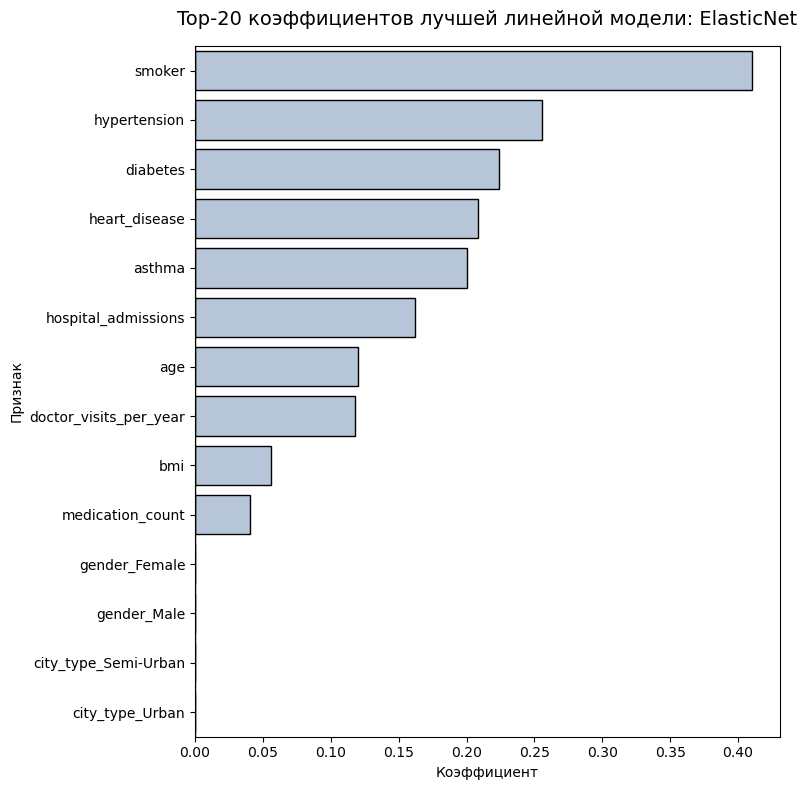

In [97]:
# Визуализация наиболее важных transformed-признаков

top_n = 20
plot_coef_df = linear_coef_df.head(top_n)

plt.figure(figsize=(8, 8))

ax = sns.barplot(
    data=plot_coef_df,
    x='coefficient',
    y='feature',
    color='lightsteelblue',
    edgecolor='black'
)

ax.axvline(0, color='black', linewidth=1)
ax.set_title(
    f'Top-{top_n} коэффициентов лучшей линейной модели: {best_linear_name}',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Коэффициент')
ax.set_ylabel('Признак')

plt.tight_layout()
plt.show()

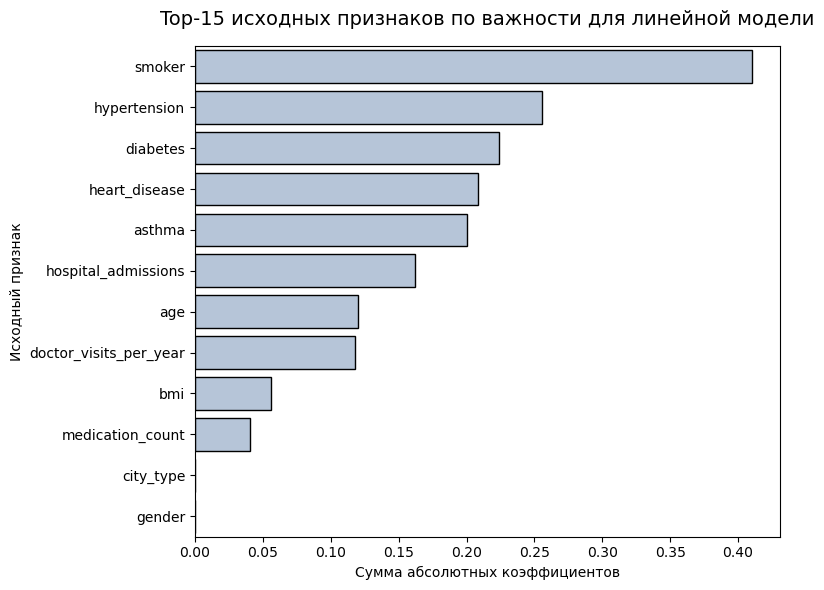

In [98]:
# Визуализация важности исходных признаков

top_n = 15
plot_original_importance = linear_original_feature_importance.head(top_n)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=plot_original_importance,
    x='importance',
    y='original_feature',
    color='lightsteelblue',
    edgecolor='black'
)

ax.set_title(
    f'Top-{top_n} исходных признаков по важности для линейной модели',
    fontsize=14,
    pad=15
)
ax.set_xlabel('Сумма абсолютных коэффициентов')
ax.set_ylabel('Исходный признак')

plt.tight_layout()
plt.show()

In [99]:
cv_results

[{'model': 'ElasticNet',
  'CV_MAE_mean': 1692.603877970841,
  'CV_MAE_std': 12.848498227769063,
  'CV_RMSE_mean': 3029.870578618592,
  'CV_RMSE_std': 36.25059176949892,
  'CV_R2_mean': 0.06847174864972069,
  'CV_R2_std': 0.007680687126173931,
  'CV_MAPE_mean': 0.7597199974074998,
  'CV_MAPE_std': 0.00947214350537727},
 {'model': 'Lasso',
  'CV_MAE_mean': 1692.6691213458478,
  'CV_MAE_std': 12.794935276583601,
  'CV_RMSE_mean': 3027.826332555165,
  'CV_RMSE_std': 36.13949637039201,
  'CV_R2_mean': 0.06972679736806046,
  'CV_R2_std': 0.0077760380341272296,
  'CV_MAPE_mean': 0.7595586206838627,
  'CV_MAPE_std': 0.009413890051296043},
 {'model': 'Ridge',
  'CV_MAE_mean': 1692.6989774679575,
  'CV_MAE_std': 12.936628820156235,
  'CV_RMSE_mean': 3030.08004605987,
  'CV_RMSE_std': 36.399636866413964,
  'CV_R2_mean': 0.06834354560120877,
  'CV_R2_std': 0.007739070377974966,
  'CV_MAPE_mean': 0.7597743281093594,
  'CV_MAPE_std': 0.009439026564391495}]

## 2. Модели на основе деревьев

В этом блоке обучаем несколько нелинейных моделей для общего пула base models: `RandomForestRegressor`, `ExtraTreesRegressor`, `HistGradientBoostingRegressor` и `CatBoostRegressor`.

Для sklearn-моделей используем общий preprocessing pipeline: числовые признаки импутируются, бинарные остаются как 0/1, категориальные признаки кодируются через one-hot encoding.  
Для CatBoost категориальные признаки оставляем в исходном виде, чтобы модель обработала их нативно.

На этом этапе подбираем гиперпараметры и фиксируем лучшие модели. OOF-предсказания будем строить позже отдельным общим блоком для всех base models.

In [101]:
# Для нового датасета нет ordinal-признаков
# gender и city_type считаем номинальными категориальными признаками

nominal_categorical_features = categorical_features.copy()

# CatBoost будет обрабатывать эти признаки нативно
catboost_cat_features = categorical_features.copy()

In [107]:
# Preprocessing для RandomForest / ExtraTrees / HistGradientBoosting
# Масштабирование не используем: деревья не чувствительны к масштабу признаков

def make_sklearn_tree_preprocessor(
    numeric_features,
    binary_features,
    nominal_categorical_features
):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    binary_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    categorical_drop_map = {
            'gender': 'Other',
            'city_type': 'Rural'
        }
    
    categorical_drop = [
            categorical_drop_map[col]
            for col in nominal_categorical_features
        ]
    
    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(
            drop=categorical_drop,
            handle_unknown='ignore',
            sparse_output=False
        ))
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('binary', binary_pipeline, binary_features),
            ('nominal', nominal_pipeline, nominal_categorical_features)
        ],
        remainder='drop',
        verbose_feature_names_out=True
    )


def make_sklearn_tree_pipeline(model):
    return Pipeline([
        ('preprocessor', make_sklearn_tree_preprocessor(
            numeric_features=numeric_features,
            binary_features=binary_features,
            nominal_categorical_features=nominal_categorical_features
        )),
        ('model', model)
    ])

In [108]:
# Helper для RandomizedSearchCV
# Для 100k строк RandomizedSearchCV практичнее, чем полный GridSearchCV

def run_random_search(
    model_name,
    pipeline,
    param_distributions,
    n_iter=20,
    random_state=RANDOM_STATE
):
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        refit='mae',
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        return_train_score=False,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f'{model_name}')
    print(f'Best CV MAE: {-search.best_score_:.4f}')
    print(f'Best params: {search.best_params_}')
    print()

    return search


# Helper для извлечения метрик лучшей модели из GridSearchCV / RandomizedSearchCV

def get_best_search_metrics(search, model_name):
    best_idx = search.best_index_

    return pd.Series({
        'model': model_name,
        'CV_MAE_mean': -search.cv_results_['mean_test_mae'][best_idx],
        'CV_MAE_std': search.cv_results_['std_test_mae'][best_idx],
        'CV_RMSE_mean': -search.cv_results_['mean_test_rmse'][best_idx],
        'CV_RMSE_std': search.cv_results_['std_test_rmse'][best_idx],
        'CV_R2_mean': search.cv_results_['mean_test_r2'][best_idx],
        'CV_R2_std': search.cv_results_['std_test_r2'][best_idx],
        'CV_MAPE_mean': -search.cv_results_['mean_test_mape'][best_idx],
        'CV_MAPE_std': search.cv_results_['std_test_mape'][best_idx]
    })

### RandomForestRegressor

In [109]:
# RandomForestRegressor

rf_pipeline = make_sklearn_tree_pipeline(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

rf_param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 6, 8, 10, 14, 18],
    'model__min_samples_split': [5, 10, 30, 100],
    'model__min_samples_leaf': [3, 10, 30, 50],
    'model__max_features': ['sqrt', 0.5, 0.8, 1.0]
}

rf_search = run_random_search(
    model_name='RandomForestRegressor',
    pipeline=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=20
)

rf_cv_result = get_best_search_metrics(
    rf_search,
    model_name='RandomForestRegressor'
)

rf_cv_result

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomForestRegressor
Best CV MAE: 1816.0123
Best params: {'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__min_samples_leaf': 30, 'model__max_features': 'sqrt', 'model__max_depth': 14}



model           RandomForestRegressor
CV_MAE_mean                1816.01226
CV_MAE_std                  12.594715
CV_RMSE_mean              2920.311053
CV_RMSE_std                 35.461853
CV_R2_mean                   0.134645
CV_R2_std                    0.004254
CV_MAPE_mean                 1.090184
CV_MAPE_std                  0.014615
dtype: object

### ExtraTreesRegressor

In [110]:
# ExtraTreesRegressor.
# Эта модель похожа на RandomForest, но строит более рандомизированные деревья.
# Она может давать другой тип ошибок, что полезно для ансамбля.

extra_trees_pipeline = make_sklearn_tree_pipeline(
    ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

extra_trees_param_distributions = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 6, 8, 10, 14, 18],
    'model__min_samples_split': [5, 10, 30, 100],
    'model__min_samples_leaf': [3, 10, 30, 50],
    'model__max_features': ['sqrt', 0.5, 0.8, 1.0]
}

extra_trees_search = run_random_search(
    model_name='ExtraTreesRegressor',
    pipeline=extra_trees_pipeline,
    param_distributions=extra_trees_param_distributions,
    n_iter=20
)

extra_trees_cv_result = get_best_search_metrics(
    extra_trees_search,
    model_name='ExtraTreesRegressor'
)

extra_trees_cv_result

Fitting 5 folds for each of 20 candidates, totalling 100 fits
ExtraTreesRegressor
Best CV MAE: 1819.9936
Best params: {'model__n_estimators': 400, 'model__min_samples_split': 100, 'model__min_samples_leaf': 30, 'model__max_features': 1.0, 'model__max_depth': 10}



model           ExtraTreesRegressor
CV_MAE_mean             1819.993608
CV_MAE_std                13.035454
CV_RMSE_mean            2922.112905
CV_RMSE_std               32.542501
CV_R2_mean                 0.133558
CV_R2_std                  0.003887
CV_MAPE_mean               1.087741
CV_MAPE_std                0.015085
dtype: object

### HistGradientBoostingRegressor

In [115]:
# Функция для оценки pipeline на CV.
# Используется внутри Optuna objective.

def evaluate_pipeline_cv_mae(pipeline, X, y, cv, trial=None):
    fold_mae = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        fold_model = clone(pipeline)
        fold_model.fit(X_fold_train, y_fold_train)

        y_fold_pred = fold_model.predict(X_fold_valid)

        mae = mean_absolute_error(
            y_fold_valid,
            y_fold_pred
        )

        fold_mae.append(mae)

        if trial is not None:
            trial.report(np.mean(fold_mae), step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    return np.mean(fold_mae)


# HistGradientBoostingRegressor с early stopping.
# max_iter задаём большим, а фактическое число итераций контролируется early stopping.

MAX_ITER_HGB = 5000

def make_hgb_pipeline_from_params(params):
    model = HistGradientBoostingRegressor(
        **params,
        max_iter=MAX_ITER_HGB,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        tol=1.0,
        scoring='neg_mean_absolute_error',
        random_state=RANDOM_STATE
    )

    return make_sklearn_tree_pipeline(model)


def hgb_objective(trial):
    params = {
        'loss': trial.suggest_categorical(
            'loss',
            ['squared_error', 'absolute_error']
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'max_leaf_nodes': trial.suggest_int(
            'max_leaf_nodes',
            8,
            127
        ),
        'max_depth': trial.suggest_categorical(
            'max_depth',
            [None, 4, 6, 8, 10, 15]
        ),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf',
            10,
            200
        ),
        'l2_regularization': trial.suggest_float(
            'l2_regularization',
            1e-8,
            100.0,
            log=True
        ),
        'max_bins': trial.suggest_int(
            'max_bins',
            64,
            255
        ),
        'max_features': trial.suggest_float(
            'max_features',
            0.5,
            1.0
        )
    }

    pipeline = make_hgb_pipeline_from_params(params)

    return evaluate_pipeline_cv_mae(
        pipeline=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        trial=trial
    )

In [116]:
# Запуск Optuna для HistGradientBoostingRegressor

N_TRIALS_HGB = 30

if OPTUNA_AVAILABLE:
    hgb_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=2)
    )

    hgb_study.optimize(
        hgb_objective,
        n_trials=N_TRIALS_HGB,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {hgb_study.best_value:.4f}')
    print(f'Best params: {hgb_study.best_params}')

  0%|          | 0/30 [00:00<?, ?it/s]

Best CV MAE: 1689.3817
Best params: {'loss': 'absolute_error', 'learning_rate': 0.01624707762012207, 'max_leaf_nodes': 125, 'max_depth': 4, 'min_samples_leaf': 126, 'l2_regularization': 0.00814922295101349, 'max_bins': 207, 'max_features': 0.5043922223293249}


In [117]:
# Финальная CV-оценка лучшей HGB-конфигурации по всем метрикам

best_hgb_pipeline = make_hgb_pipeline_from_params(
    hgb_study.best_params
)

hgb_cv_result = cross_validate_regression_model(
    model=best_hgb_pipeline,
    X=X_train,
    y=y_train,
    model_name='HistGradientBoostingRegressor',
    cv=cv,
    scoring=scoring
)

hgb_cv_result

model           HistGradientBoostingRegressor
CV_MAE_mean                       1689.381698
CV_MAE_std                          13.204457
CV_RMSE_mean                      3036.024493
CV_RMSE_std                         37.477941
CV_R2_mean                           0.064704
CV_R2_std                            0.006177
CV_MAPE_mean                         0.758535
CV_MAPE_std                          0.009521
dtype: object

In [118]:
# Обучаем лучшую HGB-модель на всём train
# Test set пока не используем

best_hgb_pipeline.fit(X_train, y_train)

hgb_model = best_hgb_pipeline.named_steps['model']

print(f'Max iterations: {hgb_model.max_iter}')
print(f'Actual iterations: {hgb_model.n_iter_}')
print(f'Early stopping used: {hgb_model.do_early_stopping_}')

Max iterations: 5000
Actual iterations: 544
Early stopping used: True


### CatBoost

In [119]:
# Preprocessing для CatBoost.
# Числовые и бинарные признаки оставляем как есть.
# Категориальные признаки передаём в CatBoost как строки.

class CatBoostPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        numeric_features,
        binary_features,
        catboost_cat_features
    ):
        self.numeric_features = numeric_features
        self.binary_features = binary_features
        self.catboost_cat_features = catboost_cat_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X_out = pd.DataFrame(index=X.index)

        # Числовые признаки
        # NaN не заполняем: CatBoost умеет работать с ними нативно
        X_out[self.numeric_features] = X[self.numeric_features]

        # Бинарные признаки оставляем как 0/1
        X_out[self.binary_features] = X[self.binary_features]

        # Категориальные признаки оставляем строковыми
        # Пропуски превращаем в отдельную категорию Missing
        for col in self.catboost_cat_features:
            X_out[col] = (
                X[col]
                .astype('object')
                .where(X[col].notna(), 'Missing')
                .astype(str)
            )

        return X_out[
            self.numeric_features
            + self.binary_features
            + self.catboost_cat_features
        ]


def make_catboost_preprocessor():
    return CatBoostPreprocessor(
        numeric_features=numeric_features,
        binary_features=binary_features,
        catboost_cat_features=catboost_cat_features
    )


def make_catboost_model(
    params,
    iterations=3000,
    early_stopping_rounds=None
):
    model_params = {
        'iterations': iterations,
        'loss_function': 'RMSE',
        'eval_metric': 'MAE',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
        'cat_features': catboost_cat_features
    }

    if early_stopping_rounds is not None:
        model_params['early_stopping_rounds'] = early_stopping_rounds

    model_params.update(params)

    return CatBoostRegressor(**model_params)


def evaluate_catboost_params_cv(
    params,
    X,
    y,
    cv,
    max_iterations=5000,
    early_stopping_rounds=50,
    trial=None
):
    fold_metrics = []
    fold_best_iterations = []

    for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X, y), start=1):
        X_fold_train = X.iloc[train_idx].copy()
        X_fold_valid = X.iloc[valid_idx].copy()

        y_fold_train = y.iloc[train_idx].copy()
        y_fold_valid = y.iloc[valid_idx].copy()

        # Preprocessing обучается только на train-части текущего фолда
        fold_preprocessor = make_catboost_preprocessor()

        X_fold_train_prepared = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_valid_prepared = fold_preprocessor.transform(X_fold_valid)

        model = make_catboost_model(
            params=params,
            iterations=max_iterations,
            early_stopping_rounds=early_stopping_rounds
        )

        model.fit(
            X_fold_train_prepared,
            y_fold_train,
            eval_set=(X_fold_valid_prepared, y_fold_valid),
            use_best_model=True
        )

        y_fold_pred = model.predict(X_fold_valid_prepared)

        metrics = calculate_regression_metrics(
            y_fold_valid,
            y_fold_pred
        )

        fold_metrics.append(metrics)
        fold_best_iterations.append(model.tree_count_)

        if trial is not None:
            current_mae = np.mean([m['MAE'] for m in fold_metrics])
            trial.report(current_mae, step=fold_id)

            if trial.should_prune():
                raise optuna.TrialPruned()

    return {
        'CV_MAE_mean': np.mean([m['MAE'] for m in fold_metrics]),
        'CV_MAE_std': np.std([m['MAE'] for m in fold_metrics]),
        'CV_RMSE_mean': np.mean([m['RMSE'] for m in fold_metrics]),
        'CV_RMSE_std': np.std([m['RMSE'] for m in fold_metrics]),
        'CV_R2_mean': np.mean([m['R2'] for m in fold_metrics]),
        'CV_R2_std': np.std([m['R2'] for m in fold_metrics]),
        'CV_MAPE_mean': np.mean([m['MAPE'] for m in fold_metrics]),
        'CV_MAPE_std': np.std([m['MAPE'] for m in fold_metrics]),
        'best_iteration_mean': np.mean(fold_best_iterations),
        'best_iteration_median': int(np.median(fold_best_iterations))
    }


def catboost_objective(trial):
    params = {
        'depth': trial.suggest_int(
            'depth',
            3,
            10
        ),
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.20,
            log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg',
            1e-2,
            100.0,
            log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength',
            0.0,
            10.0
        ),
        'bagging_temperature': trial.suggest_float(
            'bagging_temperature',
            0.0,
            10.0
        ),
        'border_count': trial.suggest_int(
            'border_count',
            32,
            255
        )
    }

    cv_result = evaluate_catboost_params_cv(
        params=params,
        X=X_train,
        y=y_train,
        cv=cv,
        max_iterations=5000,
        early_stopping_rounds=50,
        trial=trial
    )

    return cv_result['CV_MAE_mean']

In [120]:
# Запуск Optuna для CatBoost
# При необходимости можно увеличить N_TRIALS_CATBOOST до 30-50, сейчас для производительности задано низкое значение

N_TRIALS_CATBOOST = 10

if OPTUNA_AVAILABLE and CATBOOST_AVAILABLE:
    catboost_study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=RANDOM_STATE),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    )

    catboost_study.optimize(
        catboost_objective,
        n_trials=N_TRIALS_CATBOOST,
        show_progress_bar=True
    )

    print(f'Best CV MAE: {catboost_study.best_value:.4f}')
    print(f'Best params: {catboost_study.best_params}')

  0%|          | 0/10 [00:00<?, ?it/s]

Best CV MAE: 1809.3275
Best params: {'depth': 7, 'learning_rate': 0.017398074711291726, 'l2_leaf_reg': 75.56810141274431, 'random_strength': 7.7513282336111455, 'bagging_temperature': 9.394989415641891, 'border_count': 232}


In [121]:
# Финальная CV-оценка CatBoost с лучшими параметрами

best_catboost_cv_metrics = evaluate_catboost_params_cv(
    params=catboost_study.best_params,
    X=X_train,
    y=y_train,
    cv=cv,
    max_iterations=5000,
    early_stopping_rounds=50
)

catboost_cv_result = pd.Series({
    'model': 'CatBoostRegressor',
    'CV_MAE_mean': best_catboost_cv_metrics['CV_MAE_mean'],
    'CV_MAE_std': best_catboost_cv_metrics['CV_MAE_std'],
    'CV_RMSE_mean': best_catboost_cv_metrics['CV_RMSE_mean'],
    'CV_RMSE_std': best_catboost_cv_metrics['CV_RMSE_std'],
    'CV_R2_mean': best_catboost_cv_metrics['CV_R2_mean'],
    'CV_R2_std': best_catboost_cv_metrics['CV_R2_std'],
    'CV_MAPE_mean': best_catboost_cv_metrics['CV_MAPE_mean'],
    'CV_MAPE_std': best_catboost_cv_metrics['CV_MAPE_std']
})

catboost_cv_result

model           CatBoostRegressor
CV_MAE_mean           1809.327505
CV_MAE_std              12.767319
CV_RMSE_mean          2908.180381
CV_RMSE_std             34.680759
CV_R2_mean               0.141813
CV_R2_std                0.004494
CV_MAPE_mean             1.073229
CV_MAPE_std              0.014111
dtype: object

In [122]:
# Финально обучаем CatBoost на всём train
# Количество итераций берём как медиану best_iteration по CV

best_catboost_iterations = (best_catboost_cv_metrics['best_iteration_median'])

best_catboost_pipeline = Pipeline([
    ('catboost_preprocessing', make_catboost_preprocessor()),
    ('model', make_catboost_model(
        params=catboost_study.best_params,
        iterations=best_catboost_iterations,
        early_stopping_rounds=None
    ))
])

best_catboost_pipeline.fit(X_train, y_train)

print(f'CatBoost final iterations: {best_catboost_iterations}')

CatBoost final iterations: 840


### SHAP для CatBoost

In [123]:
# SHAP importance для CatBoost
# Используем нативный метод CatBoost get_feature_importance(type='ShapValues')

def get_catboost_shap_importance(
    fitted_catboost_pipeline,
    X,
    sample_size=1000
):
    sample_size = min(sample_size, len(X))

    X_sample = X.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )

    preprocessor = fitted_catboost_pipeline.named_steps['catboost_preprocessing']
    model = fitted_catboost_pipeline.named_steps['model']

    X_sample_prepared = preprocessor.transform(X_sample)

    pool = Pool(
        X_sample_prepared,
        cat_features=catboost_cat_features
    )

    shap_values = model.get_feature_importance(
        pool,
        type='ShapValues'
    )

    # Последняя колонка — base value, её не учитываем в важности признаков
    shap_feature_values = shap_values[:, :-1]

    shap_importance = pd.DataFrame({
        'feature': X_sample_prepared.columns,
        'importance': np.abs(shap_feature_values).mean(axis=0)
    })

    shap_importance = (
        shap_importance
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

    return shap_importance, shap_feature_values, X_sample_prepared

In [124]:
if CATBOOST_AVAILABLE:
    catboost_shap_importance, catboost_shap_values, catboost_shap_X = (
        get_catboost_shap_importance(
            fitted_catboost_pipeline=best_catboost_pipeline,
            X=X_train,
            sample_size=10000
        )
    )

C:\Users\dmitry.volobuev_inde\AppData\Local\Temp\ipykernel_23276\338177884.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


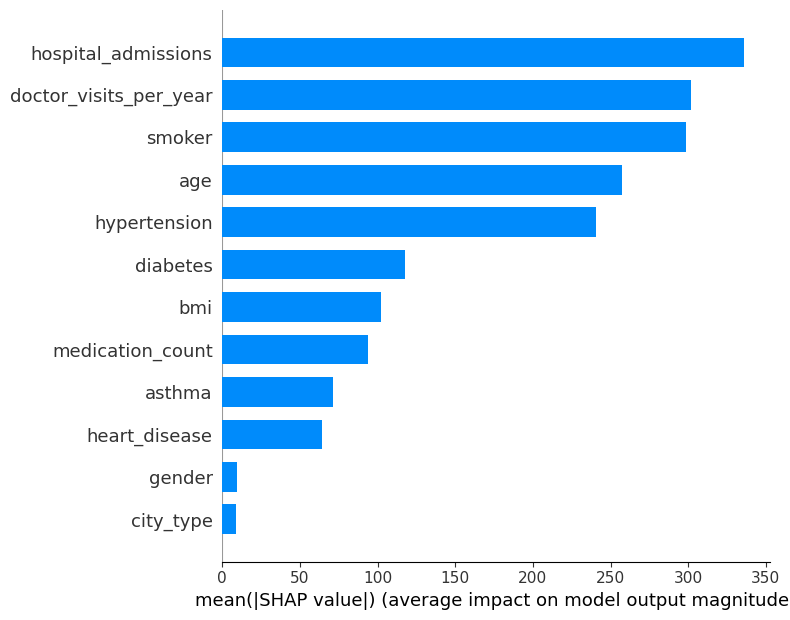

In [125]:
if SHAP_AVAILABLE and CATBOOST_AVAILABLE:
    shap.summary_plot(
        catboost_shap_values,
        catboost_shap_X,
        plot_type='bar',
        max_display=20
    )

### Результаты моделей на основе деревьев

In [126]:
# Собираем CV-результаты деревянных моделей

tree_cv_results = pd.DataFrame([
    rf_cv_result,
    extra_trees_cv_result,
    hgb_cv_result,
    catboost_cv_result
])

tree_cv_results = tree_cv_results.sort_values(
    by='CV_MAE_mean',
    ascending=True
).reset_index(drop=True)


# Сохраняем fitted-модели.
# Они обучены только на train и будут использоваться позже для OOF/test логики

tree_fitted_models = {
    'RandomForestRegressor': rf_search.best_estimator_,
    'ExtraTreesRegressor': extra_trees_search.best_estimator_,
    'HistGradientBoostingRegressor': best_hgb_pipeline,
    'CatBoostRegressor': best_catboost_pipeline
}

In [127]:
# Добавляем результаты в общую таблицу CV-результатов

tree_model_names = set(tree_cv_results['model'])

cv_results = [
    row for row in cv_results
    if row.get('model') not in tree_model_names
]

cv_results.extend(tree_cv_results.to_dict('records'))

all_cv_results = (
    pd.DataFrame(cv_results)
    .sort_values('CV_MAE_mean')
    .reset_index(drop=True)
)

all_cv_results.round(4)

,model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
0,HistGradientBoostingRegressor,1689.3817,13.2045,3036.0245,37.4779,0.0647,0.0062,0.7585,0.0095
1,ElasticNet,1692.6039,12.8485,3029.8706,36.2506,0.0685,0.0077,0.7597,0.0095
2,Lasso,1692.6691,12.7949,3027.8263,36.1395,0.0697,0.0078,0.7596,0.0094
3,Ridge,1692.6990,12.9366,3030.0800,36.3996,0.0683,0.0077,0.7598,0.0094
4,CatBoostRegressor,1809.3275,12.7673,2908.1804,34.6808,0.1418,0.0045,1.0732,0.0141
5,RandomForestRegressor,1816.0123,12.5947,2920.3111,35.4619,0.1346,0.0043,1.0902,0.0146
6,ExtraTreesRegressor,1819.9936,13.0355,2922.1129,32.5425,0.1336,0.0039,1.0877,0.0151


На этом этапе зафиксированы основные нелинейные base models.  
Следующий шаг - собрать финальный набор базовых моделей и получить out-of-fold predictions, которые будут использоваться для расчёта весов ансамблей и обучения stacking-модели.

## Out-of-fold predictions и ансамбли

На этом шаге строим честные out-of-fold предсказания базовых моделей на train.  
Каждый объект получает прогноз от модели, которая не видела его при обучении.

OOF-предсказания используются для:

- оценки качества базовых моделей;
- расчёта весов ансамблей;
- построения pseudo-BMA;
- обучения stacking meta-model.

In [129]:
# Финальный набор базовых моделей для ансамблей
# Используем одну лучшую линейную модель + основные нелинейные модели

base_models = {
    f'BestLinear_{best_linear_name}': best_linear_model,
    'RandomForestRegressor': tree_fitted_models['RandomForestRegressor'],
    'ExtraTreesRegressor': tree_fitted_models['ExtraTreesRegressor'],
    'HistGradientBoostingRegressor': tree_fitted_models['HistGradientBoostingRegressor'],
    'CatBoostRegressor': tree_fitted_models['CatBoostRegressor']
}

list(base_models.keys())

['BestLinear_ElasticNet',
 'RandomForestRegressor',
 'ExtraTreesRegressor',
 'HistGradientBoostingRegressor',
 'CatBoostRegressor']

In [134]:
# Получаем OOF-предсказания на train и прогнозы на test
# Test-прогнозы пока только сохраняем, метрики на test будем считать в финальном блоке

def get_oof_and_test_predictions(
    models,
    X_train,
    y_train,
    X_test,
    cv
):
    oof_predictions = pd.DataFrame(index=X_train.index)
    test_predictions = pd.DataFrame(index=X_test.index)
    fitted_models = {}

    for model_name, model in models.items():
        print(f'Processing model: {model_name}')

        oof_pred = np.zeros(len(X_train))

        for fold_id, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
            X_fold_train = X_train.iloc[train_idx].copy()
            X_fold_valid = X_train.iloc[valid_idx].copy()

            y_fold_train = y_train.iloc[train_idx].copy()

            fold_model = clone(model)
            fold_model.fit(X_fold_train, y_fold_train)

            oof_pred[valid_idx] = fold_model.predict(X_fold_valid)

        # После OOF обучаем модель на всём train для будущего test-прогноза
        final_model = clone(model)
        final_model.fit(X_train, y_train)

        test_pred = final_model.predict(X_test)

        oof_predictions[model_name] = oof_pred
        test_predictions[model_name] = test_pred
        fitted_models[model_name] = final_model

    return oof_predictions, test_predictions, fitted_models

In [135]:
oof_predictions, base_test_predictions, final_fitted_models = get_oof_and_test_predictions(
    models=base_models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    cv=cv
)

oof_predictions.head()

Processing model: BestLinear_ElasticNet
Processing model: RandomForestRegressor
Processing model: ExtraTreesRegressor
Processing model: HistGradientBoostingRegressor
Processing model: CatBoostRegressor


,BestLinear_ElasticNet,RandomForestRegressor,ExtraTreesRegressor,HistGradientBoostingRegressor,CatBoostRegressor
0,2318.042916,2928.976890,2620.278470,2219.637056,2999.201957
1,1586.854320,2058.561269,1993.527409,1524.286014,2061.124319
2,1776.948163,2491.848624,2473.128296,1788.909094,2382.432081
3,1896.940811,2775.236415,2479.906759,2017.048918,2591.289773
4,3278.912904,4780.123854,4974.957934,3568.199569,4589.512708


In [136]:
# Оцениваем базовые модели по OOF-предсказаниям

oof_base_results = []

for model_name in oof_predictions.columns:
    metrics = calculate_regression_metrics(
        y_true=y_train,
        y_pred=oof_predictions[model_name]
    )

    metrics['model'] = model_name

    oof_base_results.append(metrics)

oof_base_results = (
    pd.DataFrame(oof_base_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

oof_base_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,HistGradientBoostingRegressor,1689.3817,3036.2558,0.0647,0.7585
1,BestLinear_ElasticNet,1692.6039,3030.0874,0.0685,0.7597
2,CatBoostRegressor,1809.3724,2908.3605,0.1418,1.0733
3,RandomForestRegressor,1816.0123,2920.5264,0.1346,1.0902
4,ExtraTreesRegressor,1819.9936,2922.2941,0.1336,1.0877


In [137]:
# Лучшая одиночная модель выбирается только по OOF-качеству

best_single_model_name = oof_base_results.loc[0, 'model']

print(f'Лучшая одиночная модель по OOF MAE: {best_single_model_name}')

Лучшая одиночная модель по OOF MAE: HistGradientBoostingRegressor


## Ансамбль 1 - Simple Average

In [138]:
# Простое среднее прогнозов всех базовых моделей

simple_average_oof_pred = oof_predictions.mean(axis=1)
simple_average_test_pred = base_test_predictions.mean(axis=1)

## Ансамбль 2 - Inverse-Error Weighted Ensemble

In [141]:
# Веса моделей обратно пропорциональны OOF-ошибке
# Чем меньше MAE модели на OOF, тем больший вес она получает

def get_inverse_error_weights(
    oof_predictions,
    y_true,
    metric='mae',
    power=1.0,
    eps=1e-8
):
    errors = {}

    for model_name in oof_predictions.columns:
        y_pred = oof_predictions[model_name]

        if metric == 'mae':
            error = mean_absolute_error(y_true, y_pred)
        elif metric == 'rmse':
            error = root_mean_squared_error(y_true, y_pred)
        else:
            raise ValueError("metric должен быть 'mae' или 'rmse'")

        errors[model_name] = error

    errors = pd.Series(errors)

    raw_weights = 1 / np.power(errors + eps, power)
    weights = raw_weights / raw_weights.sum()

    return weights.sort_values(ascending=False)

In [142]:
inverse_mae_weights = get_inverse_error_weights(
    oof_predictions=oof_predictions,
    y_true=y_train,
    metric='mae',
    power=1.0
)

inverse_mae_weights.round(4)

HistGradientBoostingRegressor    0.2088
BestLinear_ElasticNet            0.2084
CatBoostRegressor                0.1949
RandomForestRegressor            0.1942
ExtraTreesRegressor              0.1938
dtype: float64

In [143]:
inverse_weighted_oof_pred = oof_predictions.dot(inverse_mae_weights)
inverse_weighted_test_pred = base_test_predictions.dot(inverse_mae_weights)

## Ансамбль 3 - Pseudo-BMA

In [144]:
# Pseudo-BMA weights
# Используем байесовски-мотивированную идею:
# prior weights одинаковые, затем они корректируются через качество OOF-прогнозов
#
# Strict-версия использует "полный" log-likelihood и может "схлопнуться" в одну модель
# Tempered-версия мягче и обычно лучше подходит для практического ансамбля

def get_pseudo_bma_weights(
    oof_predictions,
    y_true,
    temperature=1.0,
    eps=1e-8
):
    y_true = np.asarray(y_true)
    model_names = oof_predictions.columns.tolist()

    n = len(y_true)
    k = len(model_names)

    log_scores = []

    for model_name in model_names:
        y_pred = np.asarray(oof_predictions[model_name])

        mse = np.mean((y_true - y_pred) ** 2)

        # Gaussian-inspired log-likelihood up to a constant
        log_likelihood = -0.5 * n * np.log(mse + eps)

        # Uniform prior: P(M_i) = 1 / K
        log_prior = -np.log(k)

        log_scores.append(log_prior + log_likelihood / temperature)

    log_scores = np.array(log_scores)

    # Stable softmax
    exp_scores = np.exp(log_scores - log_scores.max())
    weights = exp_scores / exp_scores.sum()

    return pd.Series(weights, index=model_names).sort_values(ascending=False)

In [145]:
# Strict pseudo-BMA: может дать почти весь вес одной модели

strict_pseudo_bma_weights = get_pseudo_bma_weights(
    oof_predictions=oof_predictions,
    y_true=y_train,
    temperature=1.0
)

strict_pseudo_bma_weights.round(4)

CatBoostRegressor                1.0
RandomForestRegressor            0.0
ExtraTreesRegressor              0.0
BestLinear_ElasticNet            0.0
HistGradientBoostingRegressor    0.0
dtype: float64

In [146]:
# Tempered pseudo-BMA: более мягкая версия
# temperature=len(y_train) переводит сумму log-likelihood ближе к среднему log-score

tempered_pseudo_bma_weights = get_pseudo_bma_weights(
    oof_predictions=oof_predictions,
    y_true=y_train,
    temperature=len(y_train)
)

tempered_pseudo_bma_weights.round(4)

CatBoostRegressor                0.2037
RandomForestRegressor            0.2029
ExtraTreesRegressor              0.2027
BestLinear_ElasticNet            0.1955
HistGradientBoostingRegressor    0.1951
dtype: float64

In [148]:
strict_pseudo_bma_oof_pred = oof_predictions.dot(strict_pseudo_bma_weights)
strict_pseudo_bma_test_pred = base_test_predictions.dot(strict_pseudo_bma_weights)

tempered_pseudo_bma_oof_pred = oof_predictions.dot(tempered_pseudo_bma_weights)
tempered_pseudo_bma_test_pred = base_test_predictions.dot(tempered_pseudo_bma_weights)

## Ансамбль 4 - Stacking

Для stacking используем RidgeCV как простую и устойчивую meta-model.
OOF-качество stacking оцениваем через дополнительную CV уже на таблице OOF-прогнозов, чтобы не получить слишком оптимистичную оценку.

In [149]:
# Meta-model для stacking

stacking_meta_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=np.logspace(-3, 4, 20)))
])

In [150]:
# Честная OOF-оценка stacking meta-model

stacking_oof_pred = cross_val_predict(
    estimator=stacking_meta_model,
    X=oof_predictions,
    y=y_train,
    cv=cv,
    n_jobs=-1
)

# Финально обучаем meta-model на всех OOF-предсказаниях train
# и применяем к test-предсказаниям базовых моделей.

stacking_meta_model.fit(oof_predictions, y_train)
stacking_test_pred = stacking_meta_model.predict(base_test_predictions)

In [151]:
# Коэффициенты stacking meta-model

stacking_weights = pd.Series(
    stacking_meta_model.named_steps['model'].coef_,
    index=oof_predictions.columns
).sort_values(ascending=False)

stacking_weights.round(4)

CatBoostRegressor                724.5919
BestLinear_ElasticNet            316.6380
HistGradientBoostingRegressor    222.7427
ExtraTreesRegressor               44.6996
RandomForestRegressor           -111.0432
dtype: float64

## OOF-оценка ансамблей

In [172]:
# OOF-предсказания ансамблей
# BestSingleModel сюда не добавляем, так как это не отдельная модель,
# а ссылка на лучшую базовую модель по OOF

ensemble_oof_predictions = pd.DataFrame({
    'SimpleAverageEnsemble': simple_average_oof_pred,
    'InverseMAEWeightedEnsemble': inverse_weighted_oof_pred,
    'StrictPseudoBMA': strict_pseudo_bma_oof_pred,
    'TemperedPseudoBMA': tempered_pseudo_bma_oof_pred,
    'StackingRidge': stacking_oof_pred
})

In [173]:
# OOF-метрики ансамблей

oof_ensemble_results = []

for model_name in ensemble_oof_predictions.columns:
    metrics = calculate_regression_metrics(
        y_true=y_train,
        y_pred=ensemble_oof_predictions[model_name]
    )

    metrics['model'] = model_name

    oof_ensemble_results.append(metrics)

oof_ensemble_results = (
    pd.DataFrame(oof_ensemble_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

oof_ensemble_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,InverseMAEWeightedEnsemble,1730.9803,2933.2321,0.1271,0.9360
1,SimpleAverageEnsemble,1733.5668,2931.5895,0.1281,0.9418
2,TemperedPseudoBMA,1734.9963,2930.7133,0.1286,0.9449
3,StrictPseudoBMA,1809.3724,2908.3605,0.1418,1.0733
4,StackingRidge,1809.9125,2906.6807,0.1428,1.0688


In [174]:
# Общая OOF-таблица: базовые модели + ансамбли

oof_all_results = pd.concat(
    [
        oof_base_results.assign(type='base_model'),
        oof_ensemble_results.assign(type='ensemble')
    ],
    ignore_index=True
)

oof_all_results = (
    oof_all_results
    .sort_values('MAE')
    .reset_index(drop=True)
)

oof_all_results.round(4)

,model,MAE,RMSE,R2,MAPE,type
0,HistGradientBoostingRegressor,1689.3817,3036.2558,0.0647,0.7585,base_model
1,BestLinear_ElasticNet,1692.6039,3030.0874,0.0685,0.7597,base_model
2,InverseMAEWeightedEnsemble,1730.9803,2933.2321,0.1271,0.9360,ensemble
3,SimpleAverageEnsemble,1733.5668,2931.5895,0.1281,0.9418,ensemble
4,TemperedPseudoBMA,1734.9963,2930.7133,0.1286,0.9449,ensemble
5,CatBoostRegressor,1809.3724,2908.3605,0.1418,1.0733,base_model
6,StrictPseudoBMA,1809.3724,2908.3605,0.1418,1.0733,ensemble
7,StackingRidge,1809.9125,2906.6807,0.1428,1.0688,ensemble
8,RandomForestRegressor,1816.0123,2920.5264,0.1346,1.0902,base_model
9,ExtraTreesRegressor,1819.9936,2922.2941,0.1336,1.0877,base_model


## Test-предсказания ансамблей без оценки

In [175]:
# Test-предсказания ансамблей
# BestSingleModel не добавляем как отдельный столбец

ensemble_test_predictions = pd.DataFrame({
    'SimpleAverageEnsemble': simple_average_test_pred,
    'InverseMAEWeightedEnsemble': inverse_weighted_test_pred,
    'StrictPseudoBMA': strict_pseudo_bma_test_pred,
    'TemperedPseudoBMA': tempered_pseudo_bma_test_pred,
    'StackingRidge': stacking_test_pred
})

In [176]:
# Итоговый набор test-предсказаний для финального сравнения:
# базовые модели + ансамбли

final_test_predictions = pd.concat(
    [
        base_test_predictions,
        ensemble_test_predictions
    ],
    axis=1
)

final_test_predictions.head()

,BestLinear_ElasticNet,RandomForestRegressor,ExtraTreesRegressor,HistGradientBoostingRegressor,CatBoostRegressor,SimpleAverageEnsemble,InverseMAEWeightedEnsemble,StrictPseudoBMA,TemperedPseudoBMA,StackingRidge
0,2456.557521,3655.589123,3567.642859,2847.920181,3749.328660,3255.407669,3238.384375,3749.328660,3264.799168,3687.451652
1,1558.387574,2251.983823,2151.525721,1649.134929,2227.419884,1967.690386,1957.364942,2227.419884,1973.353808,2168.372777
2,3516.701026,4949.853483,5379.223807,3719.609907,5158.456372,4544.768919,4518.283744,5158.456372,4559.108983,5129.547056
3,1241.171428,1880.684386,1947.230465,1252.633615,1710.236240,1606.391227,1595.999747,1710.236240,1611.851936,1650.545597
4,1739.099480,2285.351527,2160.806836,1662.175841,2223.589793,2014.204695,2005.272056,2223.589793,2019.104422,2229.213794


- `oof_predictions` — OOF-прогнозы базовых моделей;
- `base_test_predictions` — test-прогнозы базовых моделей;
- `ensemble_oof_predictions` — OOF-прогнозы ансамблей;
- `ensemble_test_predictions` — test-прогнозы ансамблей;
- `final_test_predictions` — все test-прогнозы для финального сравнения;
- `oof_all_results` — таблица качества базовых моделей и ансамблей по OOF.

## Финальная оценка на test и статистическое сравнение

На этом этапе впервые используем отложенный test set.  
Модели и ансамбли уже были выбраны по train / OOF-логике, поэтому test используется только для независимой финальной оценки.

Основное сравнение делаем против `BestSingleModel`, то есть лучшей одиночной модели, выбранной по OOF-качеству.

In [177]:
# Финальная test-оценка всех моделей и ансамблей

test_results = []

for model_name in final_test_predictions.columns:
    metrics = calculate_regression_metrics(
        y_true=y_test,
        y_pred=final_test_predictions[model_name]
    )
    metrics['model'] = model_name
    test_results.append(metrics)

test_results = (
    pd.DataFrame(test_results)
    [['model', 'MAE', 'RMSE', 'R2', 'MAPE']]
    .sort_values('MAE')
    .reset_index(drop=True)
)

test_results.round(4)

,model,MAE,RMSE,R2,MAPE
0,HistGradientBoostingRegressor,1680.1937,2976.5313,0.0652,0.7563
1,BestLinear_ElasticNet,1687.1061,2979.8906,0.0631,0.7605
2,InverseMAEWeightedEnsemble,1724.7320,2878.8767,0.1255,0.9351
3,SimpleAverageEnsemble,1727.2600,2877.2811,0.1265,0.9409
4,TemperedPseudoBMA,1728.6625,2876.4347,0.1270,0.9440
5,CatBoostRegressor,1803.4514,2858.3694,0.1380,1.0707
6,StrictPseudoBMA,1803.4514,2858.3694,0.1380,1.0707
7,StackingRidge,1805.2862,2860.6266,0.1366,1.0671
8,RandomForestRegressor,1808.5205,2864.2231,0.1344,1.0876
9,ExtraTreesRegressor,1813.9624,2869.5689,0.1312,1.0888


In [178]:
# Bootstrap confidence intervals для метрик на test

def bootstrap_metric_ci(
    y_true,
    y_pred,
    metric_func,
    n_bootstrap=1000,
    ci=0.95,
    random_state=RANDOM_STATE
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    n = len(y_true)
    values = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(n, size=n, replace=True)
        values.append(
            metric_func(y_true[sample_idx], y_pred[sample_idx])
        )

    alpha = 1 - ci

    return {
        'mean': np.mean(values),
        'ci_lower': np.quantile(values, alpha / 2),
        'ci_upper': np.quantile(values, 1 - alpha / 2)
    }

In [179]:
# Считаем 95% CI для основных метрик

metric_functions = {
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'R2': r2_score,
    'MAPE': mean_absolute_percentage_error
}

ci_rows = []

for model_name in final_test_predictions.columns:
    y_pred = final_test_predictions[model_name]

    for metric_name, metric_func in metric_functions.items():
        ci_result = bootstrap_metric_ci(
            y_true=y_test,
            y_pred=y_pred,
            metric_func=metric_func,
            n_bootstrap=1000
        )

        ci_rows.append({
            'model': model_name,
            'metric': metric_name,
            **ci_result
        })

test_metric_ci = pd.DataFrame(ci_rows)

test_metric_ci.head()

,model,metric,mean,ci_lower,ci_upper
0,BestLinear_ElasticNet,MAE,1686.870121,1653.200891,1720.269455
1,BestLinear_ElasticNet,RMSE,2978.700110,2860.710985,3098.781791
2,BestLinear_ElasticNet,R2,0.062996,0.051761,0.074338
3,BestLinear_ElasticNet,MAPE,0.760462,0.746081,0.775224
4,RandomForestRegressor,MAE,1808.400605,1778.851641,1840.067976


In [180]:
# Таблица test-метрик с 95% CI

test_metric_ci_wide = (
    test_metric_ci
    .assign(
        value_with_ci=lambda d:
            d['mean'].round(4).astype(str)
            + ' ['
            + d['ci_lower'].round(4).astype(str)
            + '; '
            + d['ci_upper'].round(4).astype(str)
            + ']'
    )
    .pivot(
        index='model',
        columns='metric',
        values='value_with_ci'
    )
    .reset_index()
)

model_order = test_results['model'].tolist()

test_metric_ci_wide['model'] = pd.Categorical(
    test_metric_ci_wide['model'],
    categories=model_order,
    ordered=True
)

test_metric_ci_wide = (
    test_metric_ci_wide
    .sort_values('model')
    .reset_index(drop=True)
)

test_metric_ci_wide

metric,model,MAE,MAPE,R2,RMSE
0,HistGradientBoostingRegressor,1679.9815 [1646.4774; 1713.4027],0.7562 [0.7427; 0.7704],0.0651 [0.0559; 0.0751],2975.3326 [2860.2482; 3096.7914]
1,BestLinear_ElasticNet,1686.8701 [1653.2009; 1720.2695],0.7605 [0.7461; 0.7752],0.063 [0.0518; 0.0743],2978.7001 [2860.711; 3098.7818]
2,InverseMAEWeightedEnsemble,1724.6198 [1693.6796; 1756.3516],0.935 [0.9178; 0.9536],0.1254 [0.1155; 0.1361],2877.8083 [2761.7355; 2997.3205]
3,SimpleAverageEnsemble,1727.1506 [1696.2995; 1758.9329],0.9408 [0.9234; 0.9595],0.1264 [0.1165; 0.1371],2876.2173 [2760.1759; 2995.6377]
4,TemperedPseudoBMA,1728.5545 [1697.7232; 1760.3664],0.9439 [0.9265; 0.9626],0.1269 [0.117; 0.1376],2875.3734 [2759.3472; 2994.7428]
5,CatBoostRegressor,1803.4176 [1773.8086; 1835.1542],1.0706 [1.0512; 1.0916],0.1377 [0.1274; 0.1489],2857.4319 [2747.1294; 2973.7676]
6,StrictPseudoBMA,1803.4176 [1773.8086; 1835.1542],1.0706 [1.0512; 1.0916],0.1377 [0.1274; 0.1489],2857.4319 [2747.1294; 2973.7676]
7,StackingRidge,1805.259 [1776.0224; 1836.9648],1.0671 [1.0472; 1.0881],0.1363 [0.1251; 0.148],2859.7153 [2750.5636; 2974.6497]
8,RandomForestRegressor,1808.4006 [1778.8516; 1840.068],1.0875 [1.0677; 1.109],0.1343 [0.1248; 0.1439],2863.2023 [2751.4031; 2979.6247]
9,ExtraTreesRegressor,1813.9244 [1784.2359; 1846.7906],1.0887 [1.0685; 1.1103],0.1309 [0.1198; 0.1424],2868.7163 [2757.8766; 2985.7524]


In [181]:
# Paired bootstrap: сравниваем MAE каждой модели с BestSingleModel
# Если CI разницы полностью ниже 0 — модель устойчиво лучше BestSingleModel
# Если CI включает 0 — статистически значимой разницы по MAE не видно

def paired_bootstrap_mae_diff(
    y_true,
    y_pred_model,
    y_pred_reference,
    n_bootstrap=1000,
    ci=0.95,
    random_state=RANDOM_STATE
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    y_pred_model = np.asarray(y_pred_model)
    y_pred_reference = np.asarray(y_pred_reference)

    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(n, size=n, replace=True)

        mae_model = mean_absolute_error(
            y_true[sample_idx],
            y_pred_model[sample_idx]
        )
        mae_reference = mean_absolute_error(
            y_true[sample_idx],
            y_pred_reference[sample_idx]
        )

        diffs.append(mae_model - mae_reference)

    alpha = 1 - ci

    return {
        'MAE_diff_mean': np.mean(diffs),
        'ci_lower': np.quantile(diffs, alpha / 2),
        'ci_upper': np.quantile(diffs, 1 - alpha / 2)
    }

In [182]:
best_single_model_name

'HistGradientBoostingRegressor'

In [183]:
# Референсная модель — лучшая одиночная модель, выбранная по OOF

reference_model_name = best_single_model_name
reference_pred = final_test_predictions[reference_model_name]

print(f'Референсная одиночная модель: {reference_model_name}')
reference_pred = final_test_predictions[reference_model_name]

bootstrap_comparison_rows = []

for model_name in final_test_predictions.columns:
    if model_name == reference_model_name:
        continue

    diff_result = paired_bootstrap_mae_diff(
        y_true=y_test,
        y_pred_model=final_test_predictions[model_name],
        y_pred_reference=reference_pred,
        n_bootstrap=1000
    )

    bootstrap_comparison_rows.append({
        'model': model_name,
        'compared_with': reference_model_name,
        **diff_result
    })

bootstrap_mae_comparison = (
    pd.DataFrame(bootstrap_comparison_rows)
    .sort_values('MAE_diff_mean')
    .reset_index(drop=True)
)

bootstrap_mae_comparison.round(4)

Референсная одиночная модель: HistGradientBoostingRegressor


,model,compared_with,MAE_diff_mean,ci_lower,ci_upper
0,BestLinear_ElasticNet,HistGradientBoostingRegressor,6.8886,3.2438,10.9634
1,InverseMAEWeightedEnsemble,HistGradientBoostingRegressor,44.6383,37.6133,51.9589
2,SimpleAverageEnsemble,HistGradientBoostingRegressor,47.1690,39.9317,54.6589
3,TemperedPseudoBMA,HistGradientBoostingRegressor,48.5729,41.2471,56.1598
4,CatBoostRegressor,HistGradientBoostingRegressor,123.4360,112.1379,135.0724
5,StrictPseudoBMA,HistGradientBoostingRegressor,123.4360,112.1379,135.0724
6,StackingRidge,HistGradientBoostingRegressor,125.2774,113.3900,137.3944
7,RandomForestRegressor,HistGradientBoostingRegressor,128.4191,117.0627,139.8529
8,ExtraTreesRegressor,HistGradientBoostingRegressor,133.9428,122.2121,146.0571


In [184]:
# Wilcoxon signed-rank test по абсолютным ошибкам
# Это дополнительная проверка: сравниваем ошибки моделей на одних и тех же test-объектах

try:
    from scipy.stats import wilcoxon

    wilcoxon_rows = []

    reference_abs_error = np.abs(y_test - reference_pred)

    for model_name in final_test_predictions.columns:
        if model_name == reference_model_name:
            continue

        model_abs_error = np.abs(
            y_test - final_test_predictions[model_name]
        )

        stat, p_value = wilcoxon(
            model_abs_error,
            reference_abs_error,
            alternative='two-sided'
        )

        wilcoxon_rows.append({
            'model': model_name,
            'compared_with': reference_model_name,
            'wilcoxon_stat': stat,
            'p_value': p_value
        })

    wilcoxon_results = (
        pd.DataFrame(wilcoxon_rows)
        .sort_values('p_value')
        .reset_index(drop=True)
    )

    display(wilcoxon_results)

except ImportError:
    print('scipy не установлен: Wilcoxon test пропущен.')

,model,compared_with,wilcoxon_stat,p_value
0,ExtraTreesRegressor,HistGradientBoostingRegressor,80948593.5,1.809315e-120
1,RandomForestRegressor,HistGradientBoostingRegressor,82164369.5,7.875852e-106
2,CatBoostRegressor,HistGradientBoostingRegressor,83005639.0,2.905952e-96
3,StrictPseudoBMA,HistGradientBoostingRegressor,83005639.0,2.905952e-96
4,StackingRidge,HistGradientBoostingRegressor,83064850.0,1.316176e-95
5,TemperedPseudoBMA,HistGradientBoostingRegressor,89522926.5,1.012374e-37
6,SimpleAverageEnsemble,HistGradientBoostingRegressor,89676926.0,1.136236e-36
7,InverseMAEWeightedEnsemble,HistGradientBoostingRegressor,89963521.0,9.308772e-35
8,BestLinear_ElasticNet,HistGradientBoostingRegressor,98797020.0,1.390303e-01


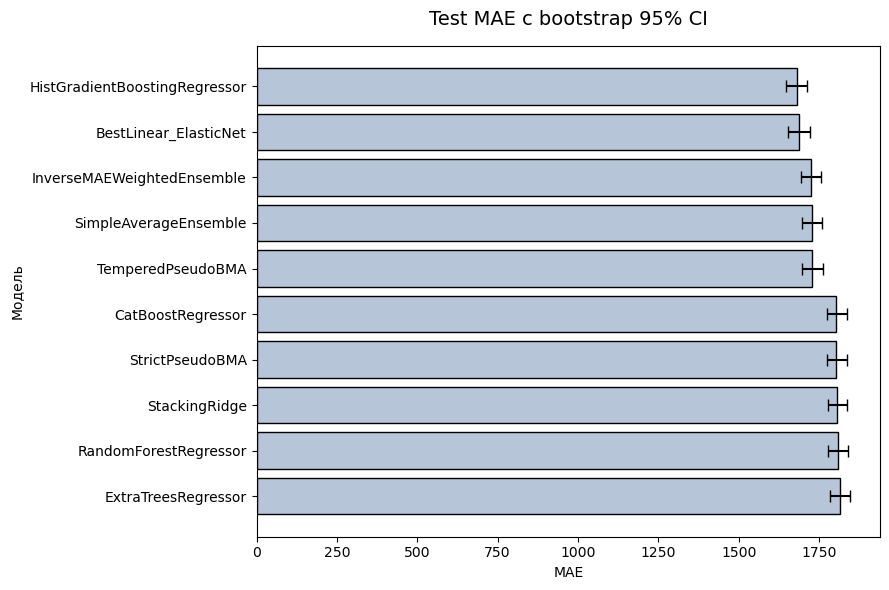

In [185]:
# Визуализация test MAE с bootstrap 95% CI

mae_ci = (
    test_metric_ci
    .query("metric == 'MAE'")
    .copy()
)

mae_ci['model'] = pd.Categorical(
    mae_ci['model'],
    categories=model_order,
    ordered=True
)

mae_ci = mae_ci.sort_values('model')

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=mae_ci,
    x='mean',
    y='model',
    color='lightsteelblue',
    edgecolor='black'
)

xerr = np.vstack([
    mae_ci['mean'] - mae_ci['ci_lower'],
    mae_ci['ci_upper'] - mae_ci['mean']
])

ax.errorbar(
    x=mae_ci['mean'],
    y=np.arange(len(mae_ci)),
    xerr=xerr,
    fmt='none',
    color='black',
    capsize=4
)

ax.set_title('Test MAE с bootstrap 95% CI', fontsize=14, pad=15)
ax.set_xlabel('MAE')
ax.set_ylabel('Модель')

plt.tight_layout()
plt.show()

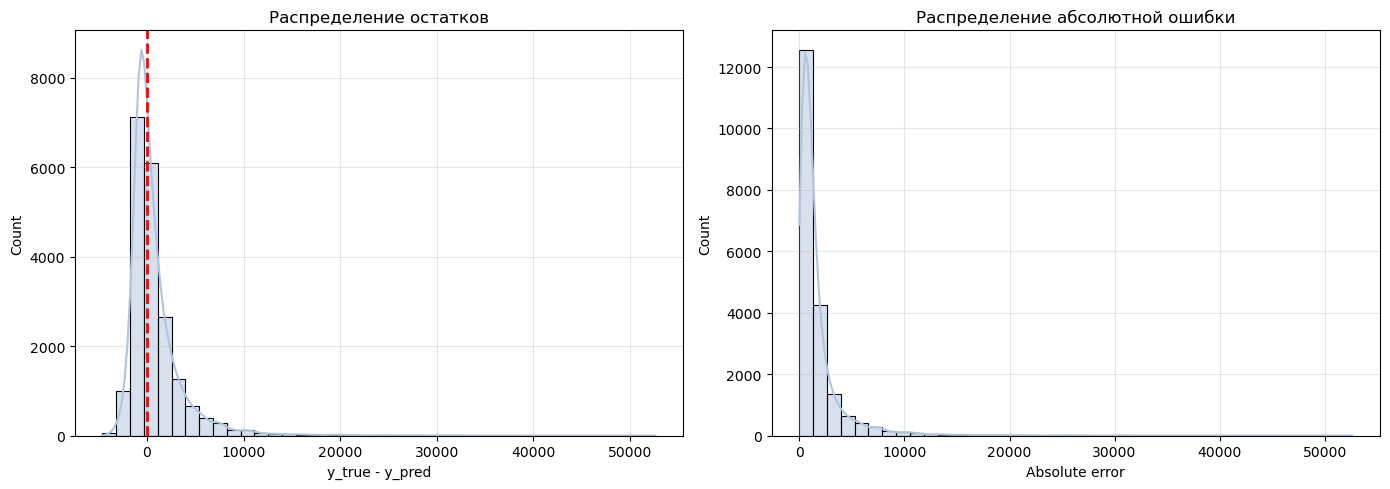

In [187]:
# Остатки для лучшей по OOF модели/ансамбля

residuals = y_test - best_oof_test_pred
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Распределение остатков')
axes[0].set_xlabel('y_true - y_pred')
axes[0].grid(alpha=0.3)

sns.histplot(
    abs_errors,
    bins=40,
    kde=True,
    color='lightsteelblue',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Распределение абсолютной ошибки')
axes[1].set_xlabel('Absolute error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Итоговые выводы по финальному сравнению

- Лучшей одиночной моделью по OOF-качеству был выбран `HistGradientBoostingRegressor`, поэтому именно он использовался как референсная модель для финального статистического сравнения.

- На test set `HistGradientBoostingRegressor` также показал лучший результат по основной метрике `MAE`. Это значит, что в среднем он даёт наименьшую абсолютную ошибку прогноза медицинских расходов.

- `BestLinear_ElasticNet` оказался очень близок к `HistGradientBoostingRegressor` по MAE. По результатам Wilcoxon-теста статистически значимого отличия между ними не выявлено (`p-value ≈ 0.139`), то есть на test set нельзя уверенно утверждать, что распределения абсолютных ошибок этих двух моделей существенно различаются.

- Остальные модели и ансамбли статистически значимо отличаются от `HistGradientBoostingRegressor` по Wilcoxon-тесту. С учётом графика MAE это различие интерпретируется как ухудшение по основной метрике MAE.

- Простое усреднение, inverse-error weighted ensemble и tempered pseudo-BMA не дали выигрыша по MAE относительно лучшей одиночной модели. Это означает, что в данном эксперименте ансамбли не улучшили среднюю абсолютную ошибку прогноза.

- `StrictPseudoBMA` фактически схлопнулся в прогноз одной модели — `CatBoostRegressor`, поэтому его результат полностью совпадает с CatBoost. Это ожидаемое поведение strict pseudo-BMA, когда одна модель получает почти весь вес.

- `StackingRidge` также не улучшил качество относительно `HistGradientBoostingRegressor`. Вероятно, базовые модели дают сильно коррелированные прогнозы, а лучшая одиночная модель уже извлекает большую часть доступного сигнала из выбранных признаков.

- В целом эксперимент показал конкуренцию нескольких моделей и несколько способов их объединения, включая байесовски-мотивированное усреднение. Однако на текущем наборе общих признаков лучшим практическим решением по MAE остаётся одиночный `HistGradientBoostingRegressor`.

- Важное ограничение: модели обучались только на пересекающемся наборе признаков (с исходными данными). В отдельном эксперименте на полном наборе признаков нового датасета ансамбли могут показать себя лучше, так как у моделей появится больше информации для различающихся прогнозов.